In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
import shap
from joblib import Parallel, delayed
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
sns.set_theme(style="whitegrid")

%config InlineBackend.figure_dpi = 300

/home/gdarruda/Projects/case-sistema-recomendacao-resolucao/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Características temporais das interações

O objetivo dessa seção é entender se existem padrões diferentes determinados pelas safra e também pelo tempo no mês. Por exemplo, identificar que são mais populares em determinados períodos do ano.

In [2]:
df_interacoes = pd.read_csv("data/interacoes.csv").assign(
    timestamp=lambda df: pd.to_datetime(df["timestamp"])
)


def contratacao_por_safra(
    df_interacoes: pd.DataFrame, agrupamento: str, altura_fig: int = 7
):

    df_agrupado_safra = (
        df_interacoes.assign(safra=lambda df: df["safra"].astype("str"))
        .groupby(by=["safra", agrupamento])
        .agg(
            {
                "timestamp": "count",
                "clicou": "sum",
                "contratou": "sum",
                "receita_gerada": "sum",
            }
        )
        .rename(columns={"timestamp": "contagem"})
    )

    num_axes = len(df_agrupado_safra.columns)
    _, axs = plt.subplots(num_axes, 1, figsize=((25, altura_fig * num_axes)))

    for i, col in enumerate(df_agrupado_safra.columns):
        axs[i].set_title(f"{col.title()} por safra")

        sns.lineplot(
            data=df_agrupado_safra.reset_index().pivot(
                index="safra", columns=agrupamento, values=col
            ),
            ax=axs[i],
        )

    plt.show()


def contratacao_por_dia_do_mes(
    df_interacoes: pd.DataFrame, agrupamento: str, altura_fig: int = 7
):

    df_agrupado_dia_do_mes = (
        df_interacoes.assign(dia_mes=df_interacoes["timestamp"].dt.strftime("%d"))
        .groupby(by=["dia_mes", agrupamento])
        .agg(
            {
                "clicou": "sum",
                "contratou": "sum",
                "receita_gerada": "sum",
            }
        )
        .rename(columns={"timestamp": "contagem"})
    )

    num_axes = len(df_agrupado_dia_do_mes.columns)
    fig, axs = plt.subplots(num_axes, 1, figsize=((15, altura_fig * num_axes)))

    for i, col in enumerate(df_agrupado_dia_do_mes.columns):
        axs[i].set_title(f"{col.title()} por dia do mes")

        sns.lineplot(
            data=df_agrupado_dia_do_mes.reset_index().pivot(
                index="dia_mes", columns=agrupamento, values=col
            ),
            ax=axs[i],
        )

    plt.show()

## Análise de safra e canais

* O volume total de exibições é parecido entre as diversas safras, mas existe uma diferença constante entre canais. Interessante perceber que mesmo canais proativos tem variações, indicando alguma estratégia pro-ativas (e.g. aumentar ofertas do produto X nessa período do ano).
* Em termos de engajamento de cliques, a **home** e a **busca** se destacam em relação aos demais canais.
* A contratação e receita são mais expressivos pelo canal de **busca**, talvez o canal com maior propensão *a priori* já que o cliente está ativamente a procura.

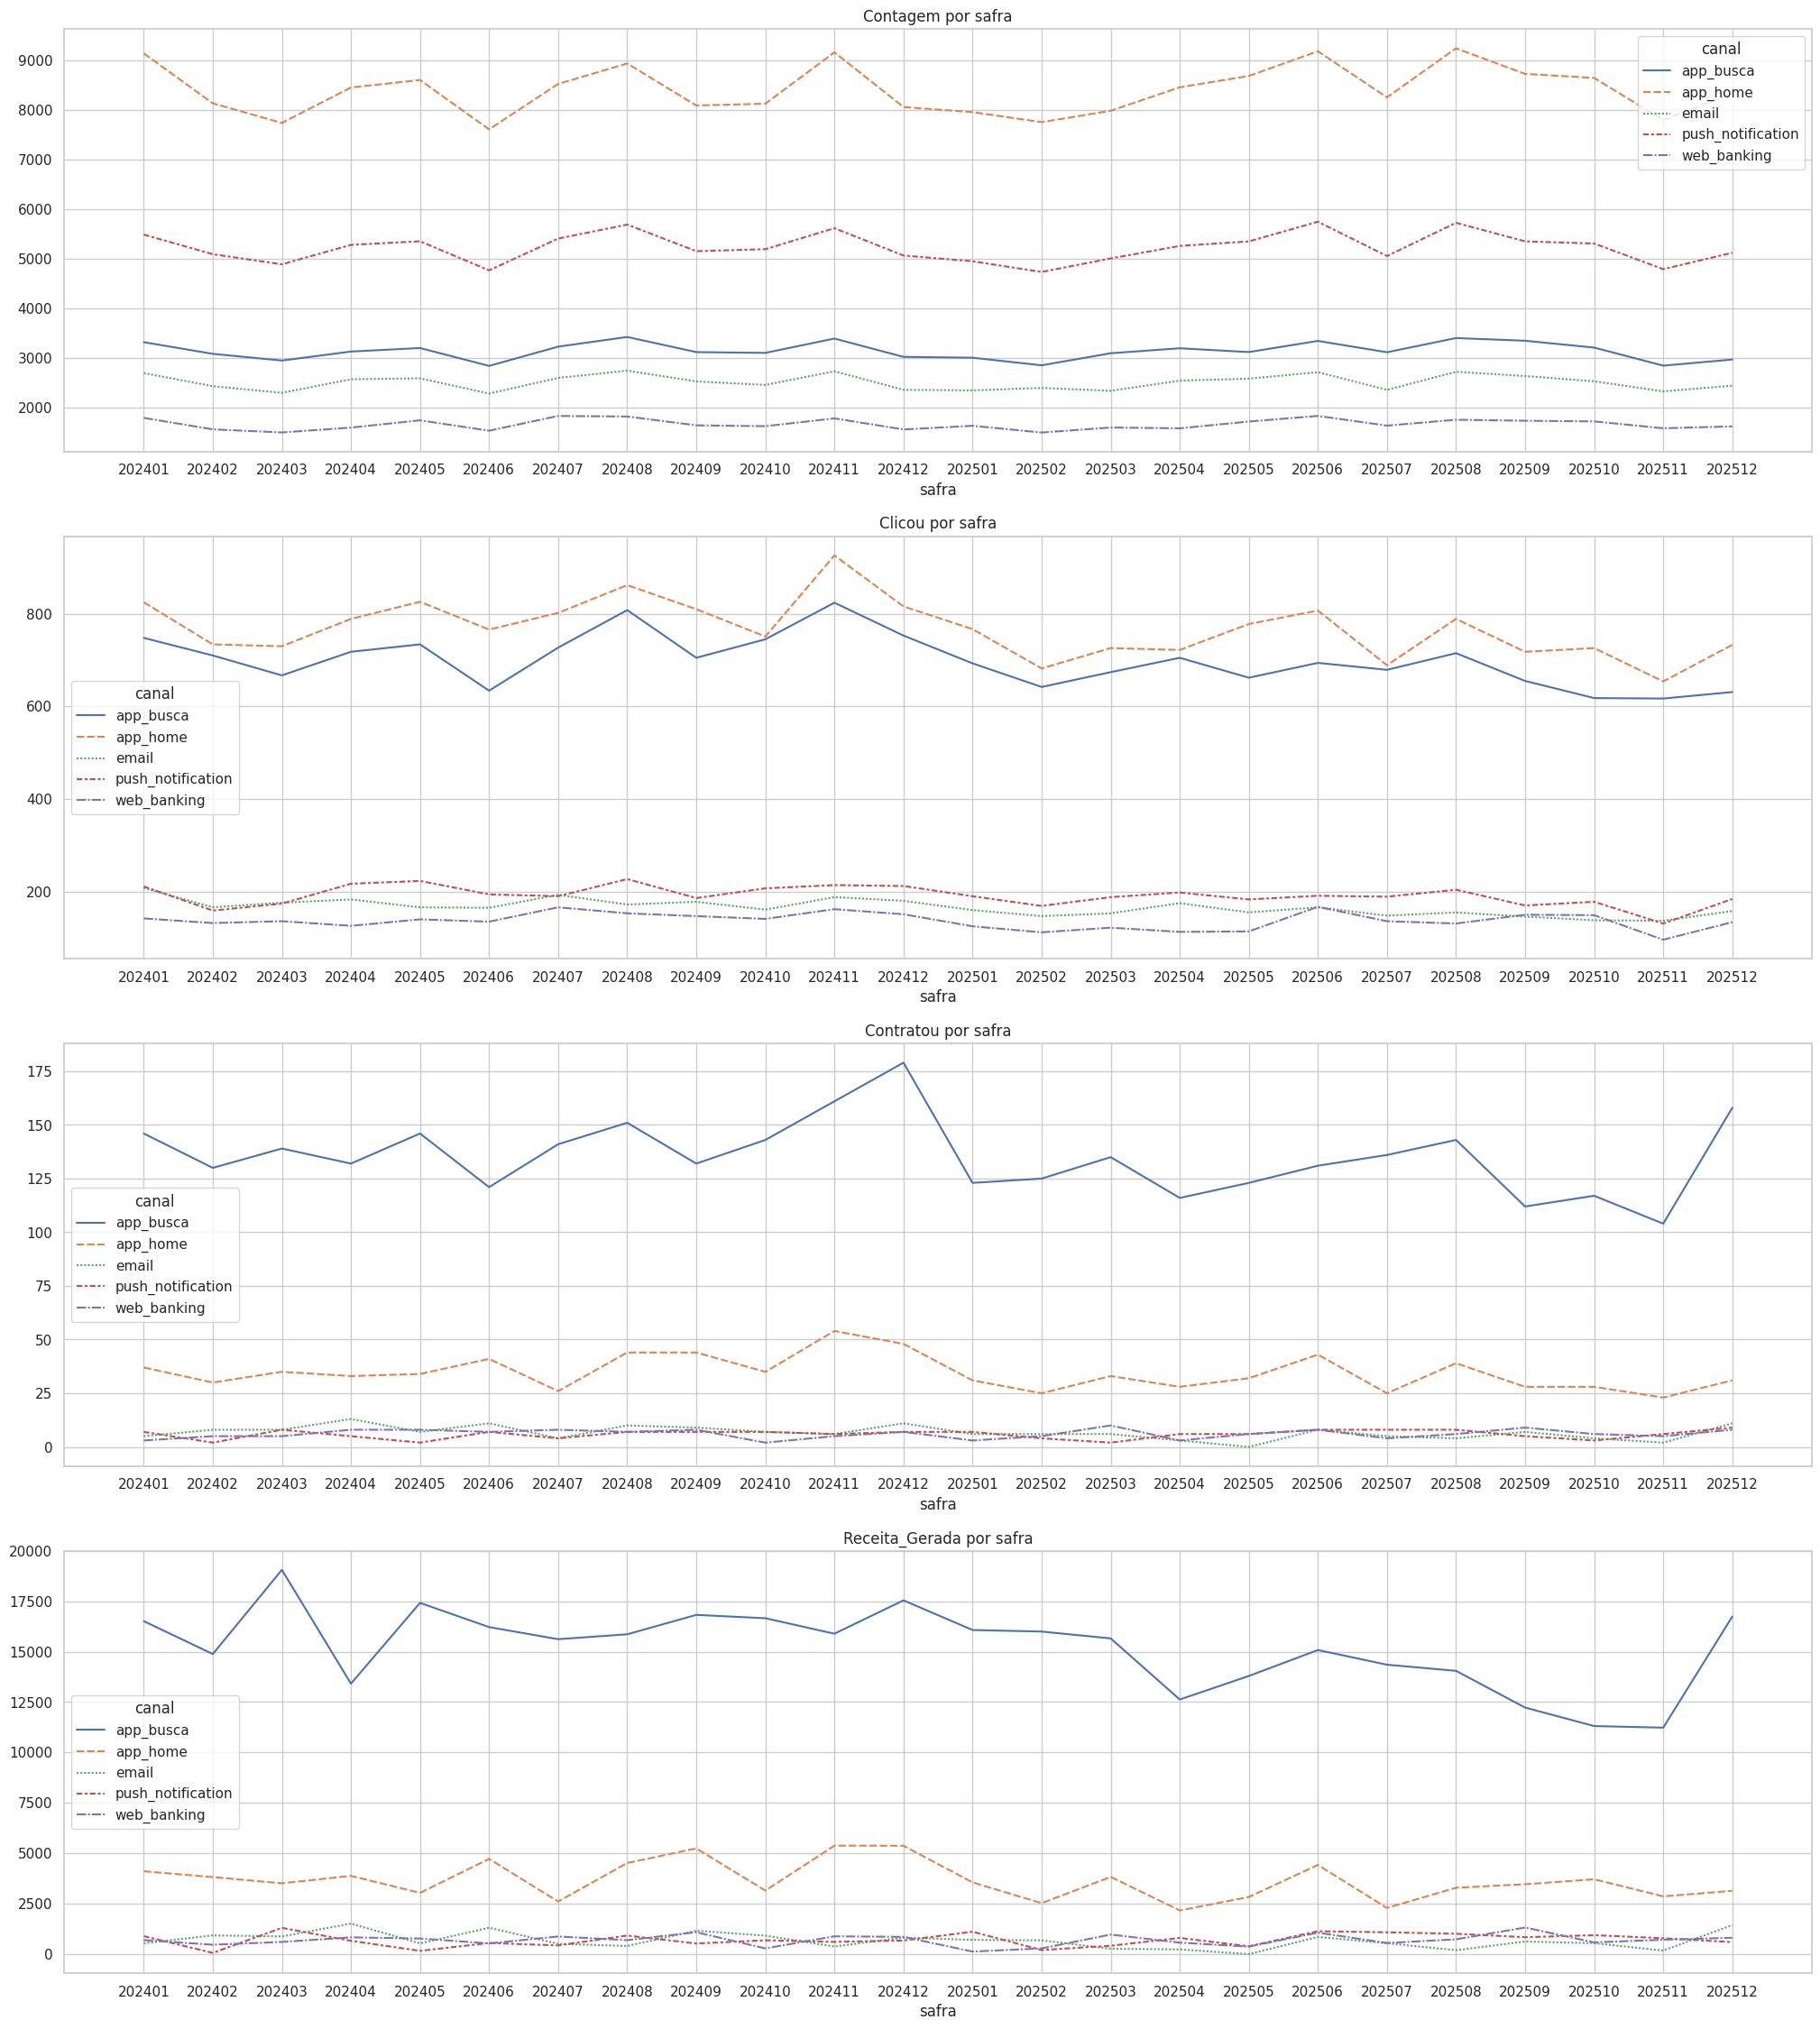

In [3]:
contratacao_por_safra(df_interacoes, "canal")

## Análise de safras e produtos

* Alguns produtos tem ciclos mais pronunciados, com destaque para **previdência** que tem picos no final do ano.
* Existe uma diferença de engajamento e contratgação a depender dos produtos, é algo que será avaliado em mais detalhes. Qual produto tem maior propensão de engajamento?
* A receita é muito dependente de produtos – faz sentido otimizar a estratégia de exibição pela receita é – é interessante avaliar essa relação de receita por produto.

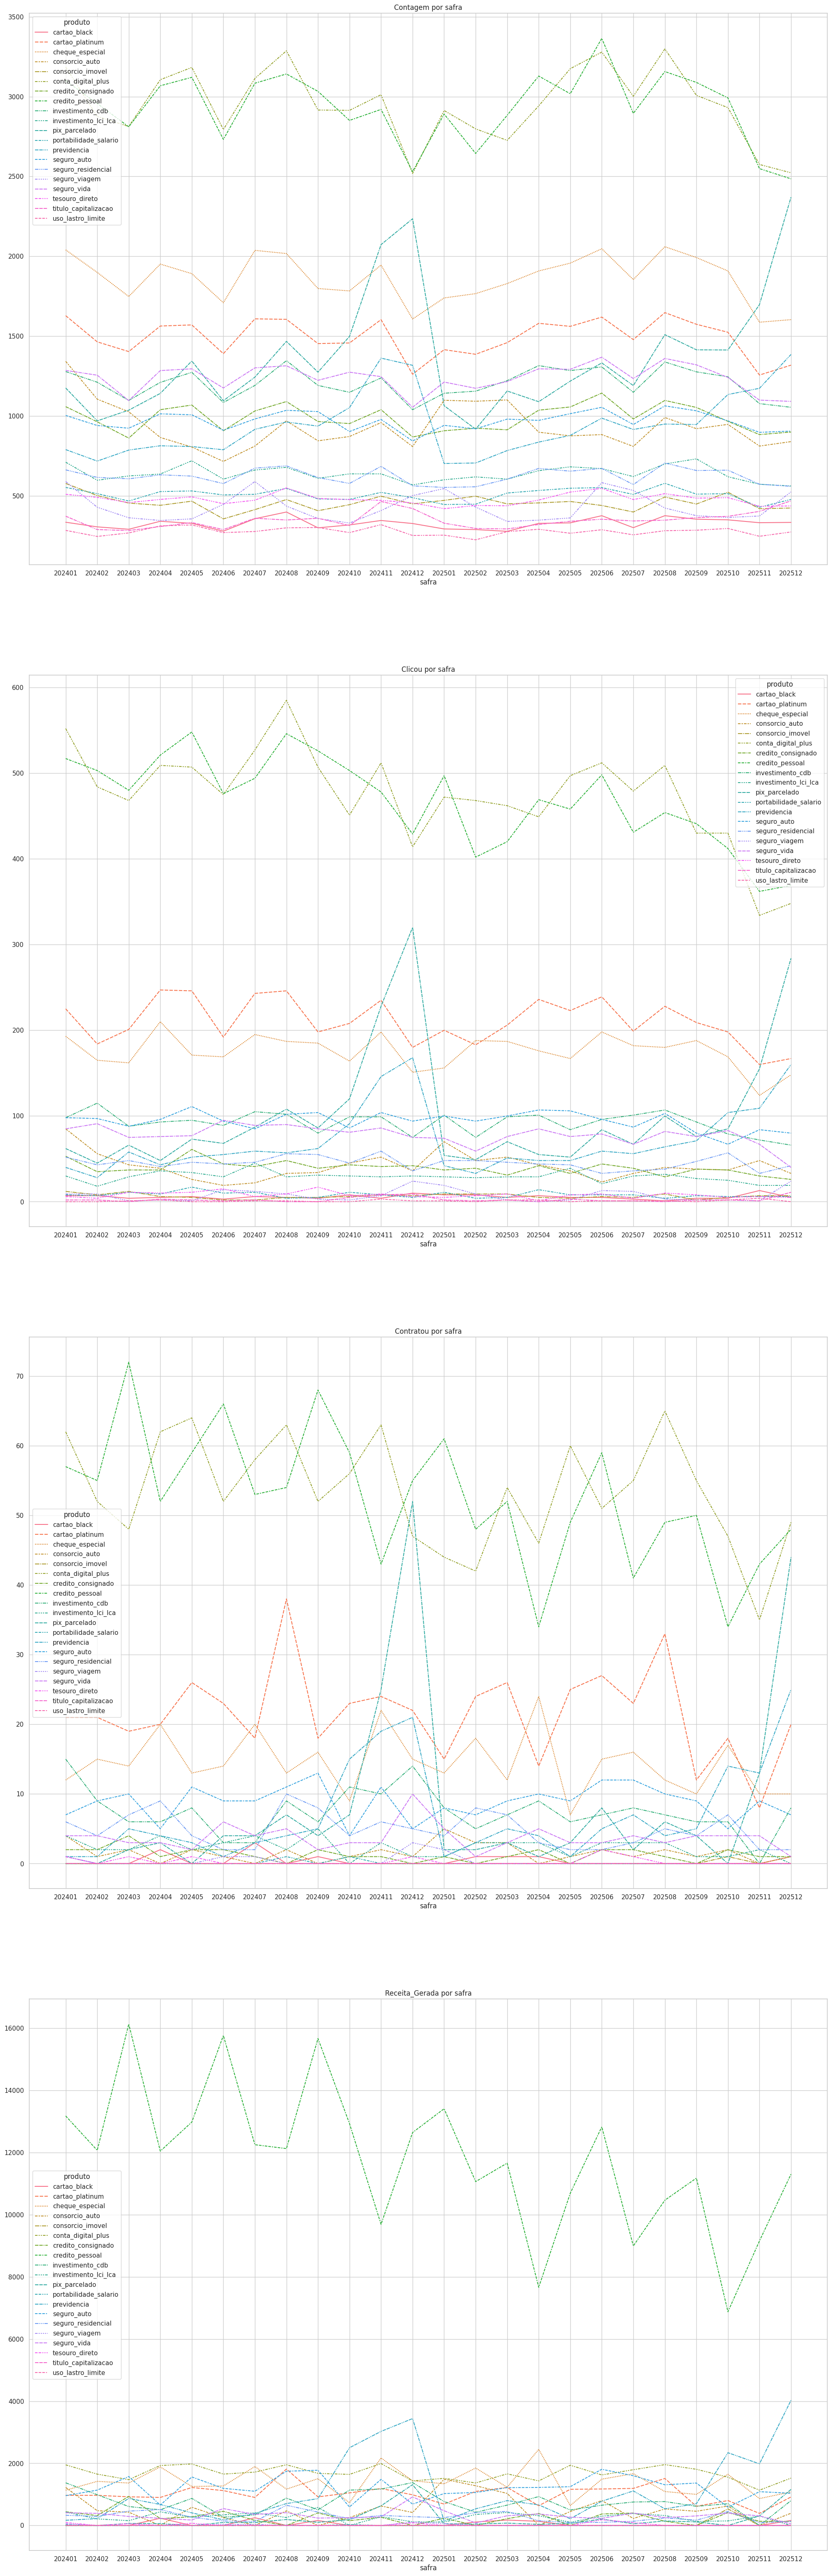

In [4]:
contratacao_por_safra(df_interacoes, "produto", altura_fig=20)

## Análise por dia do mês

Por aálise visual, não parece existir uma tendência muito proeminente detro da safra. Imagino que esses detalhes sejam mais críticos para comunicações pró-ativas, como seria o caso de e-mails e notificações. Para a recomendação dentro app ou a partir da busca, não parece ser algo muito crítico no comportamento.

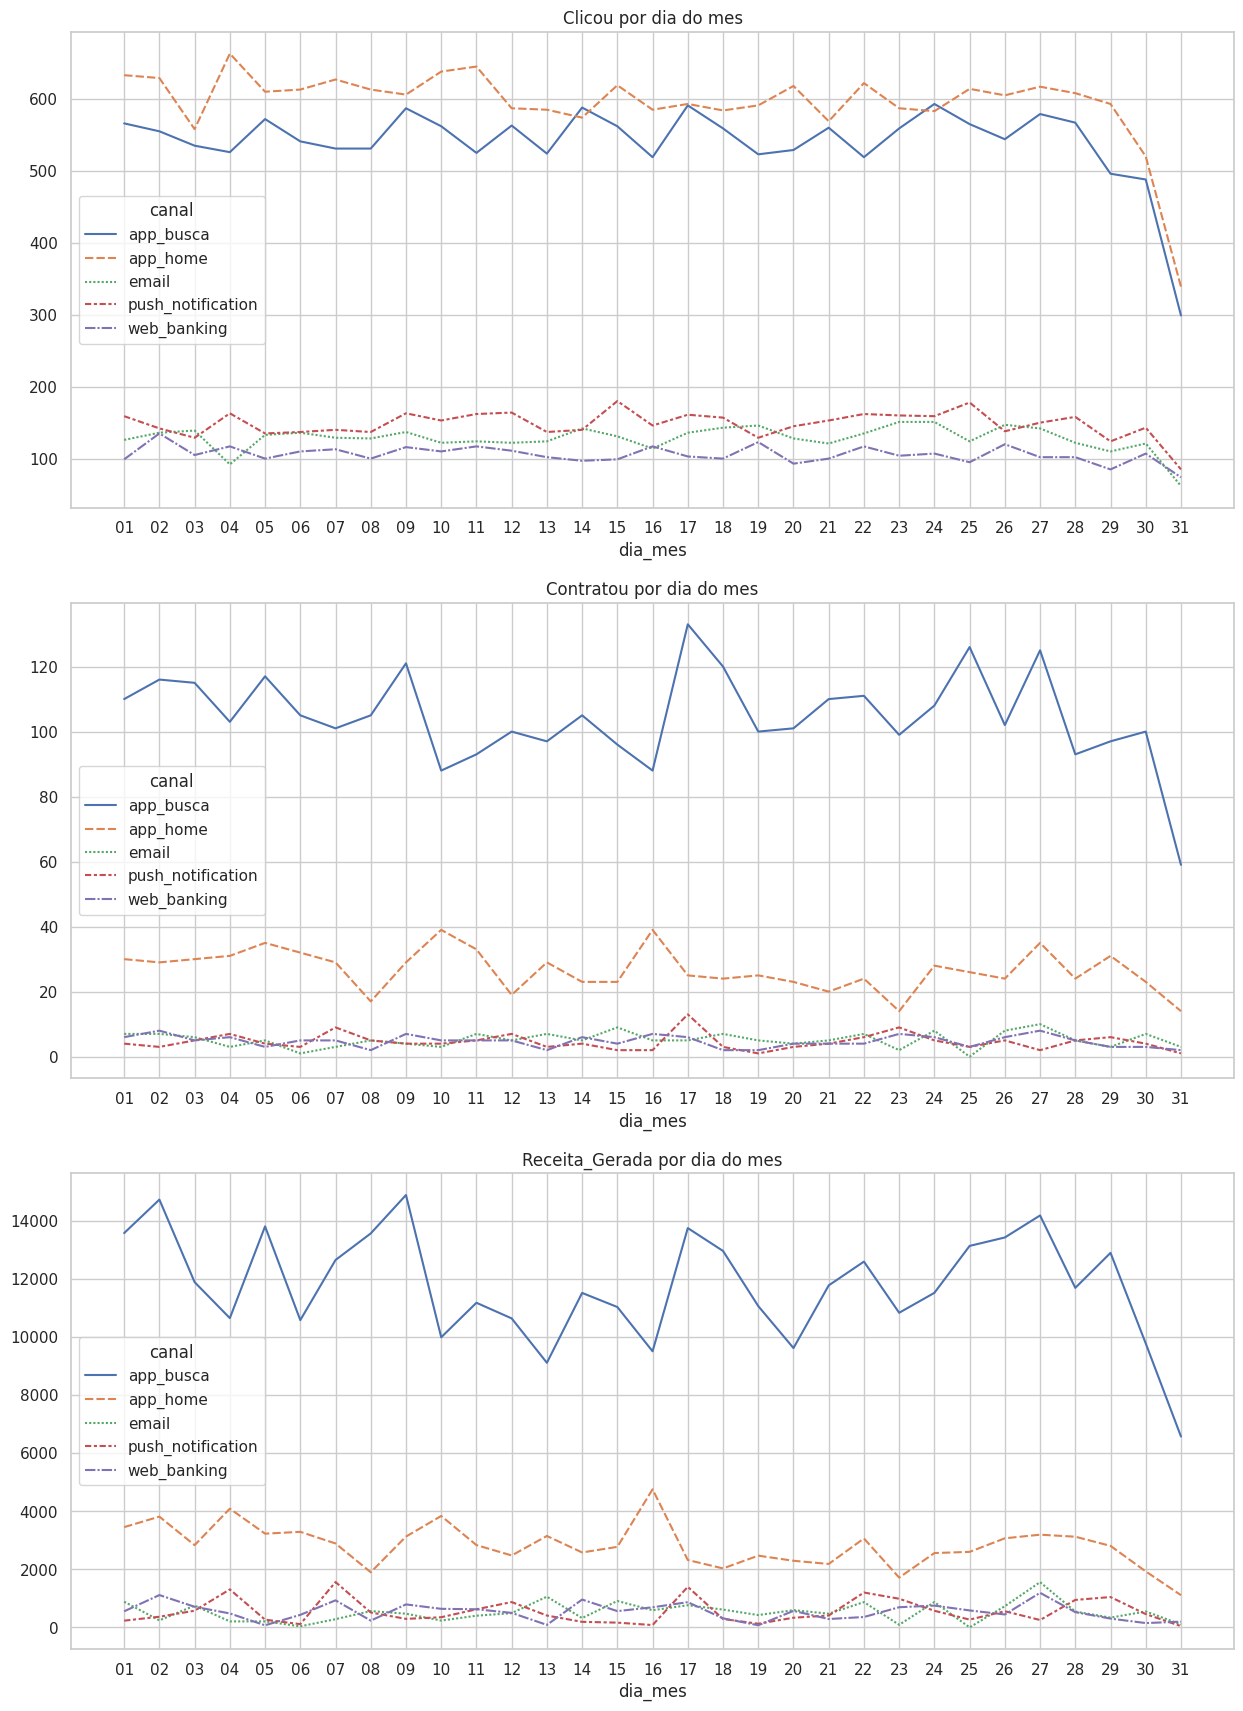

In [5]:
contratacao_por_dia_do_mes(df_interacoes, "canal")

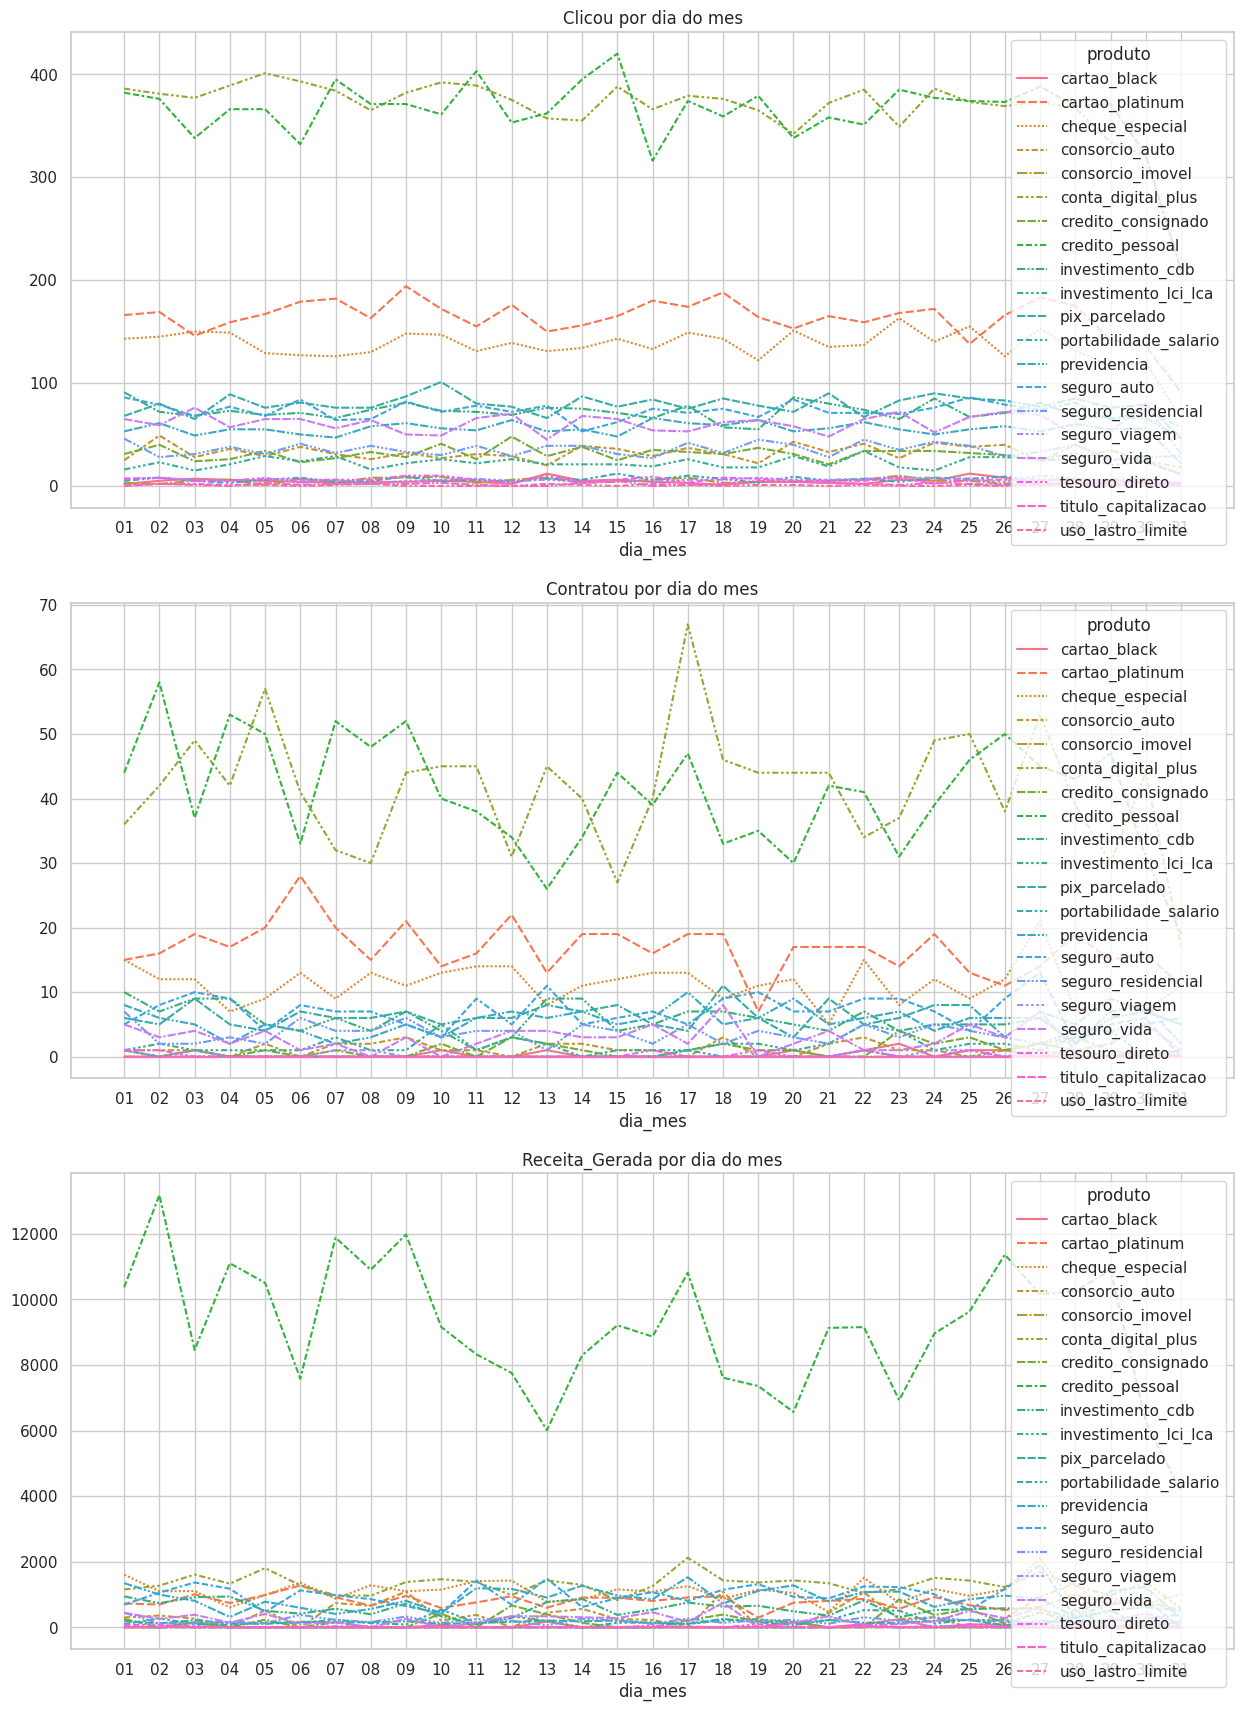

In [6]:
contratacao_por_dia_do_mes(df_interacoes, "produto")

# Análise de propensão dos produtos e canais

A ideia é entender como os canais e os produtos interferem na propensão de contratação, entender a característica "do que" está sendo recomendado e "como" está sendo recomendado.

In [32]:
def grafico_propensao_geral(df_interacoes: pd.DataFrame):
    df_probabilidade_posicao = (
        df_interacoes.groupby(["posicao_exibicao"])
        .agg(
            {
                "id_interacao": "count",
                "clicou": "sum",
                "contratou": "sum",
                "receita_gerada": "sum",
            }
        )
        .rename(columns={"id_interacao": "contagem"})
        .assign(
            probabilidade_contratacao=lambda df: df["contratou"] / df["contagem"],
            probabilidade_clicar=lambda df: df["clicou"] / df["contagem"],
            receita_esperada=lambda df: df["receita_gerada"] / df["contagem"],
            contratacao_cumulativo=lambda df: (
                df["contratou"] / df["contratou"].sum()
            ).cumsum(),
            cliques_cumulativo=lambda df: (df["clicou"] / df["clicou"].sum()).cumsum(),
            receita_cumulativa=lambda df: (
                df["receita_gerada"] / df["receita_gerada"].sum()
            ).cumsum(),
        )
    )

    _, axs = plt.subplots(2, 3, figsize=((25, 10)))

    plots = [
        ("probabilidade_clicar", "Probilidade Clicar", (0, 0)),
        ("probabilidade_contratacao", "Probilidade Contratação", (0, 1)),
        ("receita_esperada", "Receita Esperada", (0, 2)),
        ("cliques_cumulativo", "Cliques comulativo", (1, 0)),
        ("contratacao_cumulativo", "Contratação cumulativa", (1, 1)),
        ("receita_cumulativa", "Receita cumulativa", (1, 2)),
    ]

    for col, title, (row, col_idx) in plots:
        sns.lineplot(
            data=df_probabilidade_posicao[[col]]
            .rename(columns={col: title})
            .rename_axis("Posição Exibição"),
            ax=axs[row, col_idx],
        )

    plt.tight_layout()
    plt.show()


def _popularidade_canal_produto(df_interacoes: pd.DataFrame) -> pd.DataFrame:
    return (
        df_interacoes.groupby(["produto", "canal"])
        .agg(
            {
                "id_interacao": "count",
                "clicou": "sum",
                "contratou": "sum",
                "receita_gerada": "sum",
            }
        )
        .rename(columns={"id_interacao": "contagem"})
        .assign(
            probabilidade_clicar=lambda df: df["clicou"] / df["contagem"],
            probabilidade_contratacao=lambda df: df["contratou"] / df["contagem"],
            receita_esperada=lambda df: df["receita_gerada"] / df["contagem"],
        )
        .reset_index()
    )


def grafico_propensao_canal_produto(df_interacoes: pd.DataFrame):
    df_interacoes_agregadas = _popularidade_canal_produto(df_interacoes)

    _, axs = plt.subplots(1, 3, figsize=((35, 10)))

    for idx, metrica in enumerate(
        ["probabilidade_clicar", "probabilidade_contratacao", "receita_esperada"]
    ):
        axs[idx].set_title(metrica)

        sns.heatmap(
            df_interacoes_agregadas.pivot_table(
                index="produto",
                columns="canal",
                values=metrica,
            ),
            ax=axs[idx],
        )


def grafico_melhor_canal_produto(df_interacoes: pd.DataFrame):
    valores = {
        "app_busca": 5,
        "app_home": 4,
        "web_banking": 3,
        "email": 1,
        "push_notification": 2,
    }

    index = ["app_busca", "app_home", "web_banking", "push_notification", "email"]

    df_interacoes_agregadas = _popularidade_canal_produto(df_interacoes)

    _, axs = plt.subplots(1, 3, figsize=((35, 10)))

    for idx, metrica in enumerate(
        [
            "probabilidade_clicar",
            "probabilidade_contratacao",
            "receita_esperada",
        ]
    ):
        df_canais_propensos = pd.DataFrame(index=index)

        axs[idx].set_title(metrica)

        for produto in df_interacoes_agregadas["produto"].drop_duplicates():
            df_canais_propensos[produto] = (
                df_interacoes_agregadas.query(f"produto == '{produto}'")
                .sort_values(metrica, ascending=False)
                .reset_index()["canal"]
                .map(valores)
                .set_axis(index)
            )

        sns.heatmap(df_canais_propensos.transpose(), ax=axs[idx])


def propensao_pos_clique(df_interacoes: pd.DataFrame):

    def propensao_produto(df_interacoes: pd.DataFrame) -> pd.DataFrame:
        denominador = (
            df_interacoes.groupby("produto")[["clicou"]]
            .count()
            .rename(columns={"clicou": "contagem"})
        )
        numerador = df_interacoes.groupby("produto")[["contratou"]].sum()

        return denominador.join(numerador, how="left").assign(
            propensao=lambda df: df["contratou"] / df["contagem"]
        )

    df_interacoes = df_interacoes.sort_values(["id_cliente", "timestamp"])

    df_interacoes["clicou_produto_anteriormente"] = (
        df_interacoes.groupby(["id_cliente", "produto"])["clicou"]
        .cumsum()
        .groupby([df_interacoes["id_cliente"], df_interacoes["produto"]])
        .shift(1)
        .fillna(0)
        .apply(lambda x: 1 if x > 0 else 0)
    )

    df_propensao_comparada = (
        propensao_produto(df_interacoes.query("clicou_produto_anteriormente==1."))
        .join(
            propensao_produto(df_interacoes.query("clicou_produto_anteriormente==0.")),
            lsuffix="_pos_clique",
            rsuffix="_sem_clique",
        )[["propensao_sem_clique", "propensao_pos_clique"]]
        .rename(
            columns={
                "propensao_sem_clique": "Sem Clique",
                "propensao_pos_clique": "Pós Clique",
            }
        )
    ).reset_index()

    highlight_sem_clique_maior = lambda row: [
        "background-color: blue" if row["Sem Clique"] < row["Pós Clique"] else ""
        for _ in row
    ]

    return df_propensao_comparada.style.apply(
        highlight_sem_clique_maior, axis=1
    ).format({"Sem Clique": "{:.3f}", "Pós Clique": "{:.3f}"})


def receita_gerada_por_produto_interacoes(df_interacoes: pd.DataFrame):
    plt.figure(figsize=(10, 5))

    sns.barplot(
        df_interacoes.query("receita_gerada > 0")
        .groupby("produto")["receita_gerada"]
        .mean()
        .sort_values(ascending=False),
        orient="h",
    ).set_title("Ticket médio por produto")

    plt.show()

## Propensão por exibição

Conforme esperado, as interações ficam menos efetivas à medida em que a posição de exibição aumenta. Em termos de contratação e receita, os valores até a posição 5 são responsáveis por boa parte do volume. São comportamentos esperados, a probabilidade ir reduzindo e as cinco primeiras posições serem as grandes responsáveis.

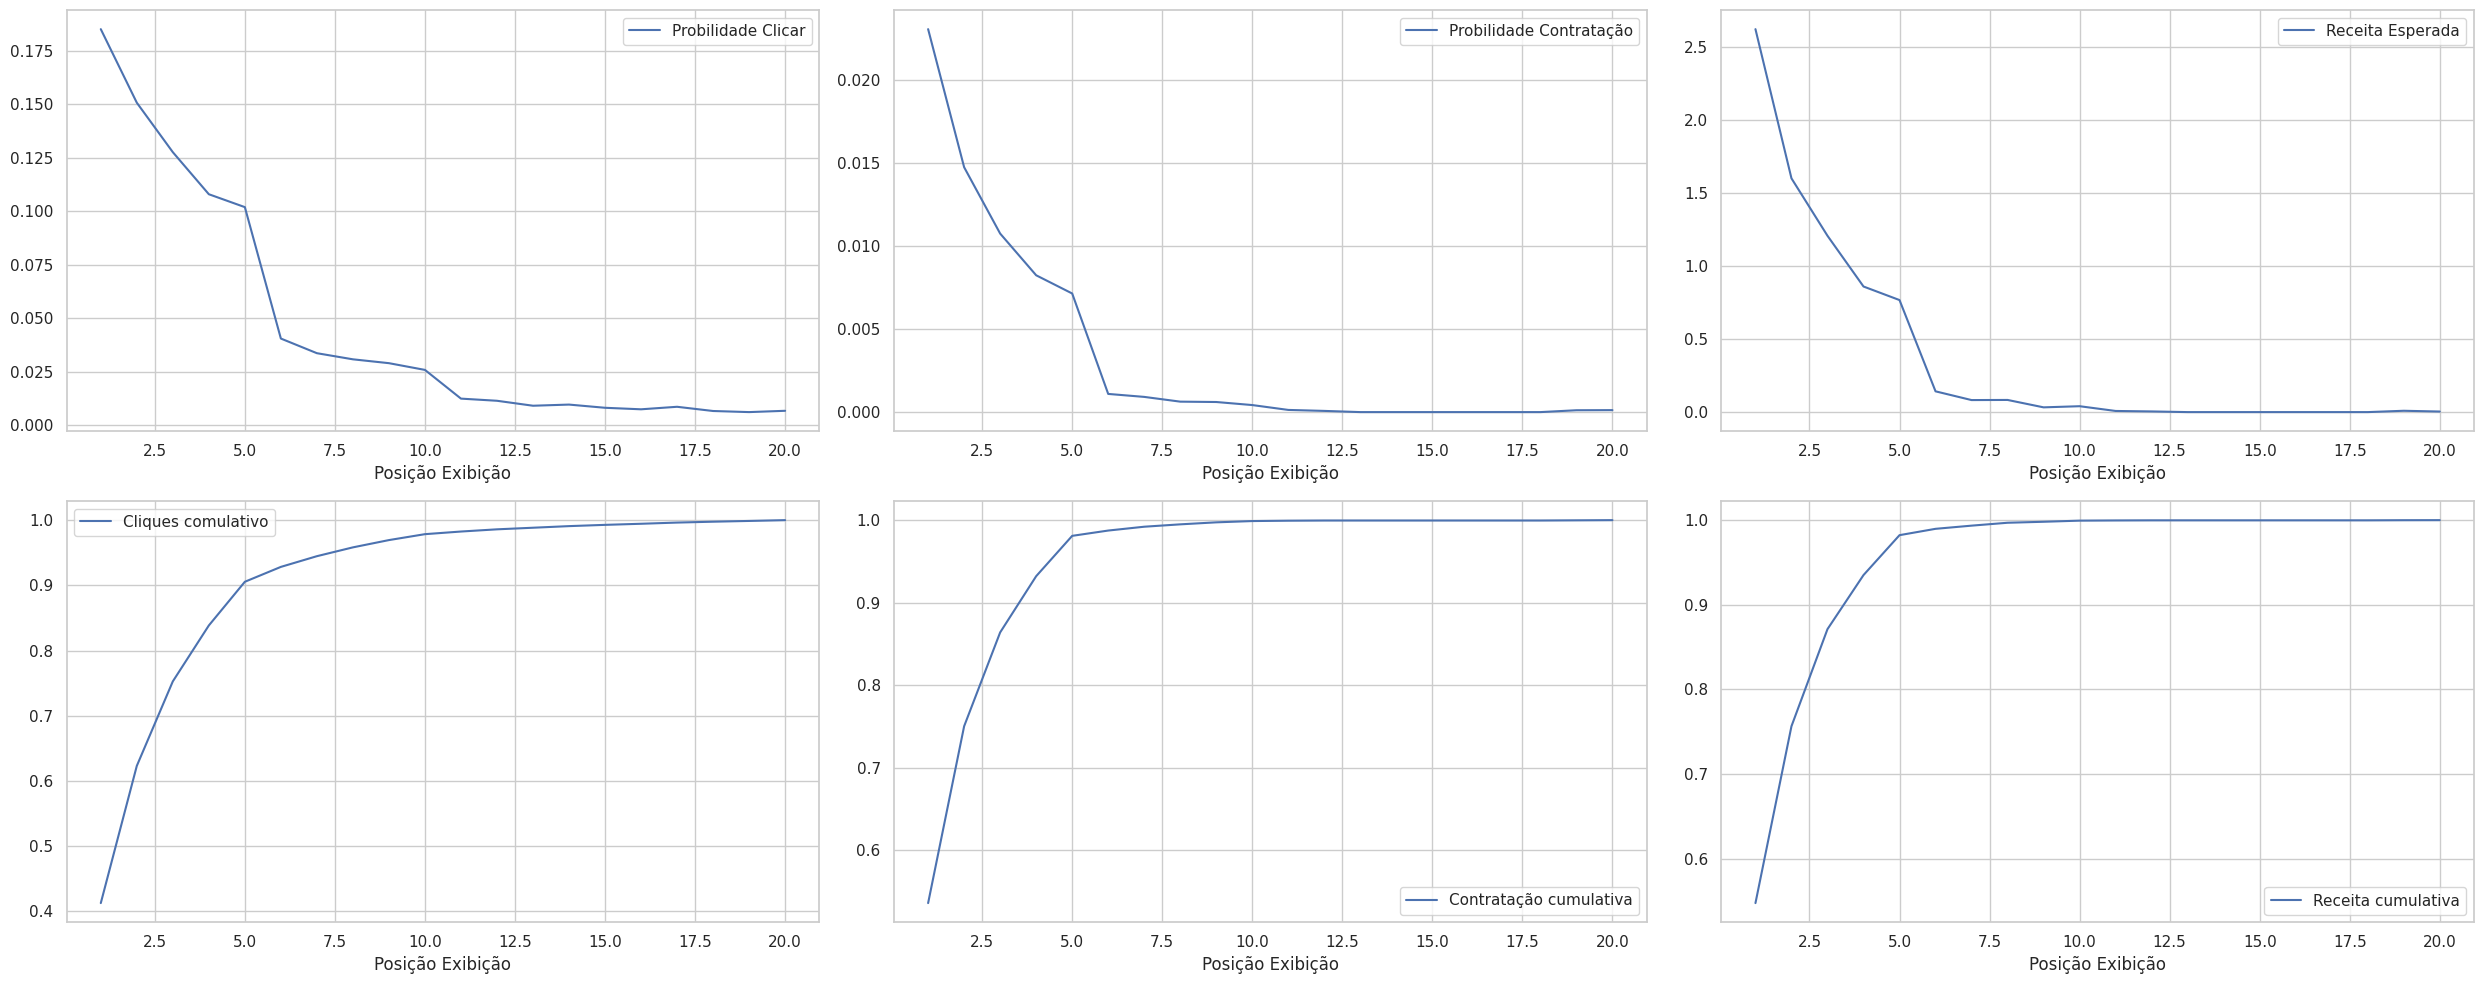

In [33]:
grafico_propensao_geral(df_interacoes)

## Propensão por produto e canal

A ideia dessa análise é entender a relação entre produtos e canais. Algum produto tem mais afinidade com algum canal?

Fazendo essa avaliação cruzada, parece que são questões pouco dependentes. No caso, a busca é o canal com mais propensão a engajamento e cliques, não importando tanto qual produto está sendo vendido.

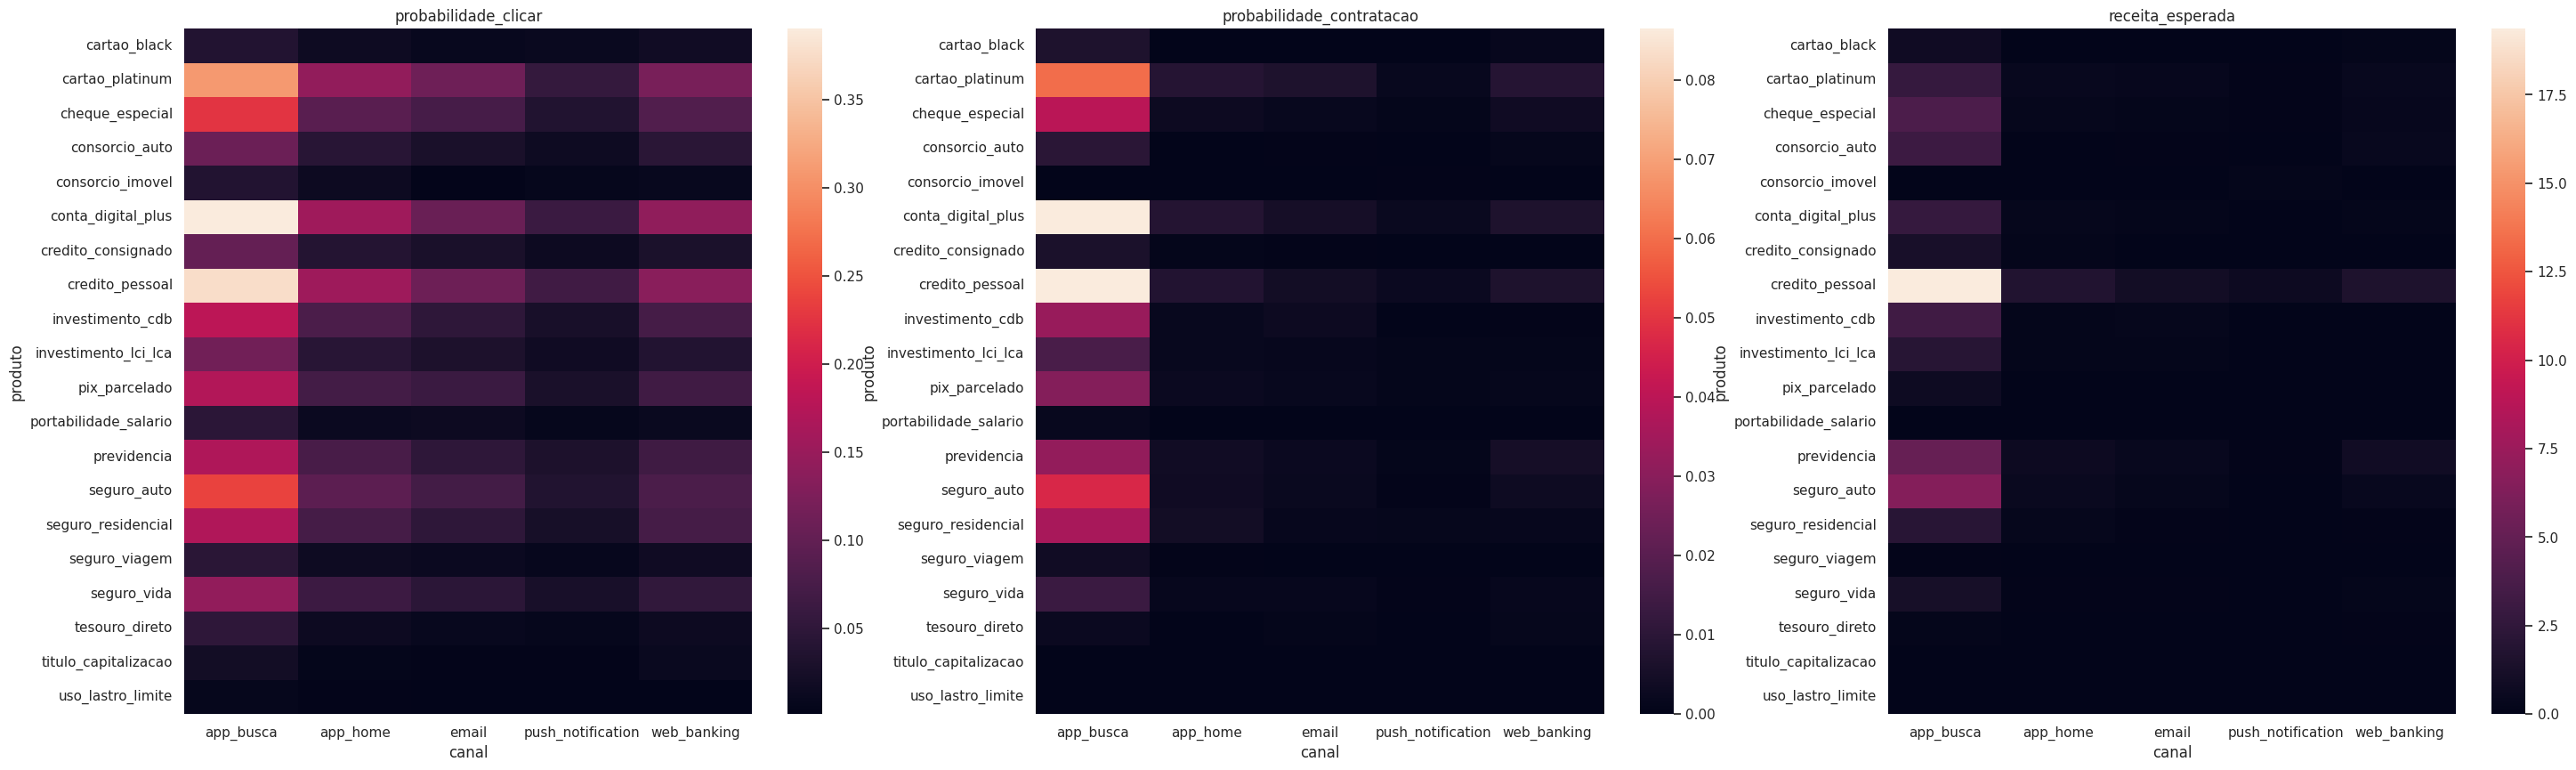

In [34]:
grafico_propensao_canal_produto(df_interacoes)

Na visualização abaixo, fica mais claro como os canais mais efetivos funcionam para a maioria dos produtos. Eu criei essa "escala" de popularidade geral com base no que foi visto na matriz acima:

| Canal | Pontuação |
|--------|-----------|
| app_busca | 5 |
| app_home | 4 |
| web_banking | 3 |
| email | 1 |
| push_notification | 2 |

Fazendo outro mapa de calor, percebe-se que esse padrão se repete para a maioria dos produtos. 

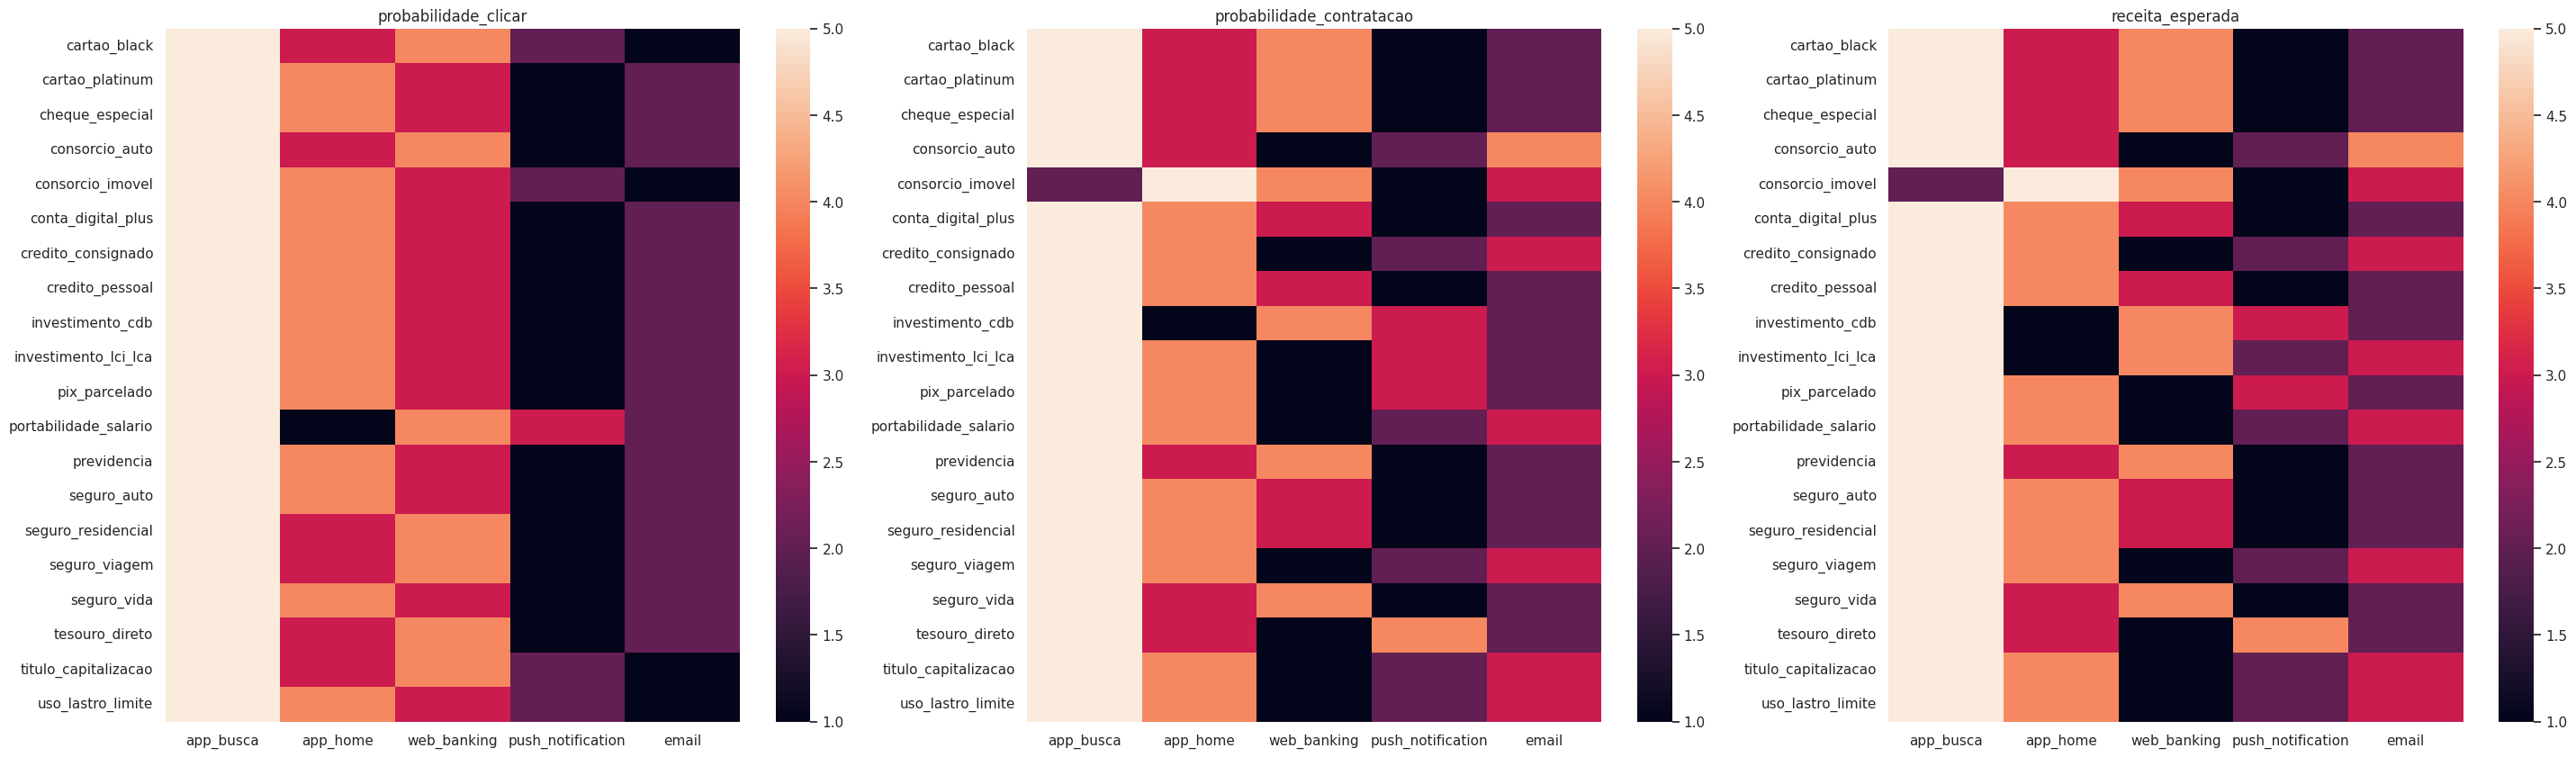

In [35]:
grafico_melhor_canal_produto(df_interacoes)

## Propensão após interações

Abaixo, podemos ver que os cliques anteriores modificam a propensão de contratação, o que pode ser uma variável importante para adicionar nos modelos.

In [36]:
propensao_pos_clique(df_interacoes)

,produto,Sem Clique,Pós Clique
0,cartao_black,0.001,0.000
1,cartao_platinum,0.013,0.026
2,cheque_especial,0.008,0.012
3,consorcio_auto,0.002,0.000
4,consorcio_imovel,0.000,0.000
5,conta_digital_plus,0.018,0.019
6,credito_consignado,0.001,0.008
7,credito_pessoal,0.018,0.020
8,investimento_cdb,0.006,0.012
9,investimento_lci_lca,0.004,0.000


## Ticket Médio por interação

A receita gerada tem grandes diferenças por produto, o que pode ser mais importante que simplesmente aumentar contratações, mudando o foco da otimização do modelo.

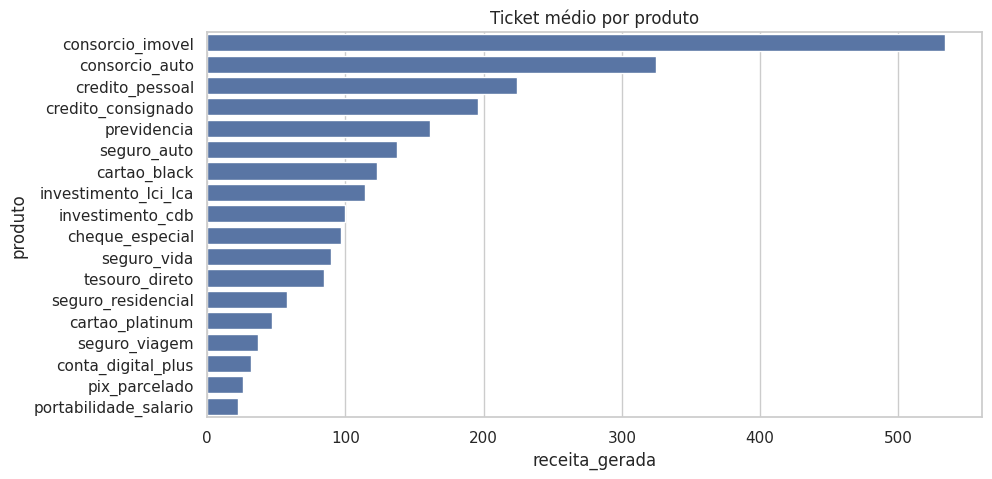

In [12]:
receita_gerada_por_produto_interacoes(df_interacoes)

# Análise produtos

A proposta dessa seção é avaliar os produtos da cesta, entendendo quais são as preferência por segmento conforme modelo baseline.

In [13]:
df_contratos = pd.read_csv("data/contratos_ativos.csv")
df_clientes = pd.read_csv("data/clientes.csv")


def _produtos_por_segmento(
    df_contratos: pd.DataFrame, df_clientes: pd.DataFrame
) -> pd.DataFrame:
    return (
        pd.merge(df_contratos, df_clientes, on="id_cliente")
        .groupby(["produto", "segmento"])["id_cliente"]
        .count()
        .reset_index()
        .rename(columns={"id_cliente": "contagem"})
    )


def contratos_por_segmento_permanencia(
    df_contratos: pd.DataFrame, df_clientes: pd.DataFrame, num_bins: int
):

    cols = min(2, num_bins)
    rows = (num_bins + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(15 * cols, 5 * rows))
    axes = np.atleast_1d(axes).flatten()

    if num_bins == 1:
        axes = [axes]

    bins = np.histogram_bin_edges(df_clientes["qtd_meses_cliente"], bins=num_bins)

    for i in range(num_bins):
        bin_start = bins[i]
        bin_end = bins[i + 1]

        df_clientes_bin = df_clientes[
            (df_clientes["qtd_meses_cliente"] >= bin_start)
            & (df_clientes["qtd_meses_cliente"] < bin_end)
        ]

        sns.barplot(
            _produtos_por_segmento(df_contratos, df_clientes_bin),
            x="contagem",
            y="produto",
            hue="segmento",
            hue_order=["basico", "intermediario", "premium"],
            orient="h",
            ax=axes[i],
        )

        axes[i].set_title(
            f"Clientes com {i + 1}: {bin_start:.1f} até <{bin_end:.1f} meses de relacionamento"
        )

    plt.tight_layout()
    plt.show()


def contratos_por_segmento(df_contratos: pd.DataFrame, df_clientes: pd.DataFrame):

    plt.figure(figsize=(10, 5))

    sns.barplot(
        _produtos_por_segmento(df_contratos, df_clientes),
        x="contagem",
        y="produto",
        hue="segmento",
        hue_order=["basico", "intermediario", "premium"],
        orient="h",
    )

    plt.show()


def correlacao_produtos_por_segmento(
    df_contratos: pd.DataFrame, df_clientes: pd.DataFrame
):

    def get_max_corr(df_corr_basket: pd.DataFrame) -> float:
        corr_values = df_corr_basket.values.copy(order="C")
        np.fill_diagonal(corr_values, 0.0)
        return np.max(np.abs(corr_values))

    df_contratos_clientes = pd.merge(df_contratos, df_clientes, on="id_cliente")
    _, axs = plt.subplots(3, 1, figsize=((30, 30)))

    for i, segmento in enumerate(["basico", "intermediario", "premium"]):
        df_basket = (
            pd.crosstab(
                df_contratos_clientes.query(f"segmento == '{segmento}'")["id_cliente"],
                df_contratos["produto"],
            )
            > 0
        ).astype(int)

        df_corr_basket = df_basket.corr()
        max_corr = get_max_corr(df_corr_basket)

        axs[i].set_title(f" Correlação de produtos no segmento {segmento.title()}")

        sns.heatmap(
            df_corr_basket,
            annot=True,
            mask=np.triu(np.ones_like(df_corr_basket, dtype=bool)),
            cmap="coolwarm",
            fmt=".2f",
            vmin=-max_corr,
            vmax=max_corr,
            ax=axs[i],
        )

    plt.tight_layout()
    plt.show()


def tempo_relacionamento_cliente(df_clientes: pd.DataFrame):

    plt.figure(figsize=(10, 5))

    ax = sns.boxplot(
        data=df_clientes,
        x="segmento",
        order=["basico", "intermediario", "premium"],
        y="qtd_meses_cliente",
        showfliers=False,
    )

    ax.set_title("Tempo de relacionamento do cliente")

    plt.tight_layout()
    plt.show()

## Popularidade dos produtos

Conforme esperado, os produtos variam bastante de distribuição de acordo com o segmento, que é o critério atual de recomendação. Produtos como o **cartão black** – alta receita e baixo público – são oportunidades interessantes para um modelo, já que é bem difícil ter recall desse cenário.

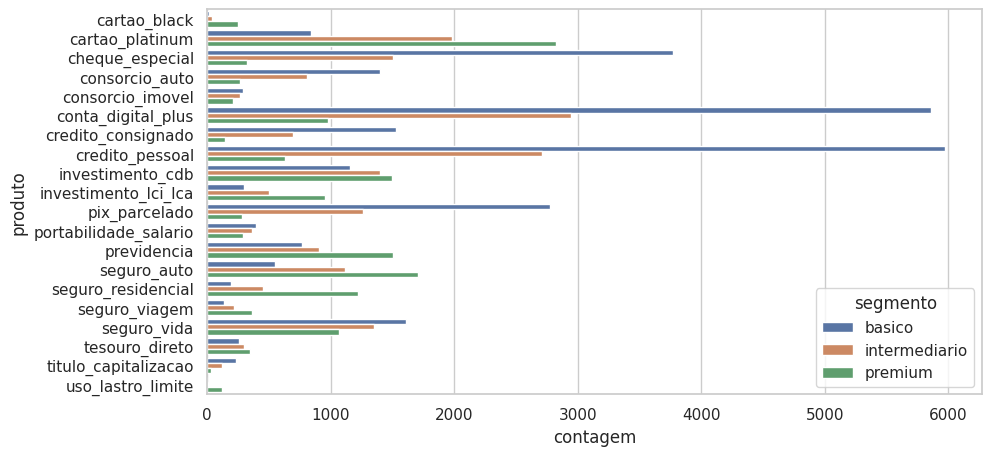

In [14]:
contratos_por_segmento(df_contratos, df_clientes)

Olhando para a distribuição no tempo, podemos perceber que clientes são "promovidos" para segmentos premium com o tempo. Nessa amostra, não há contratos de clientes premium com 6 meses de relacionamento.

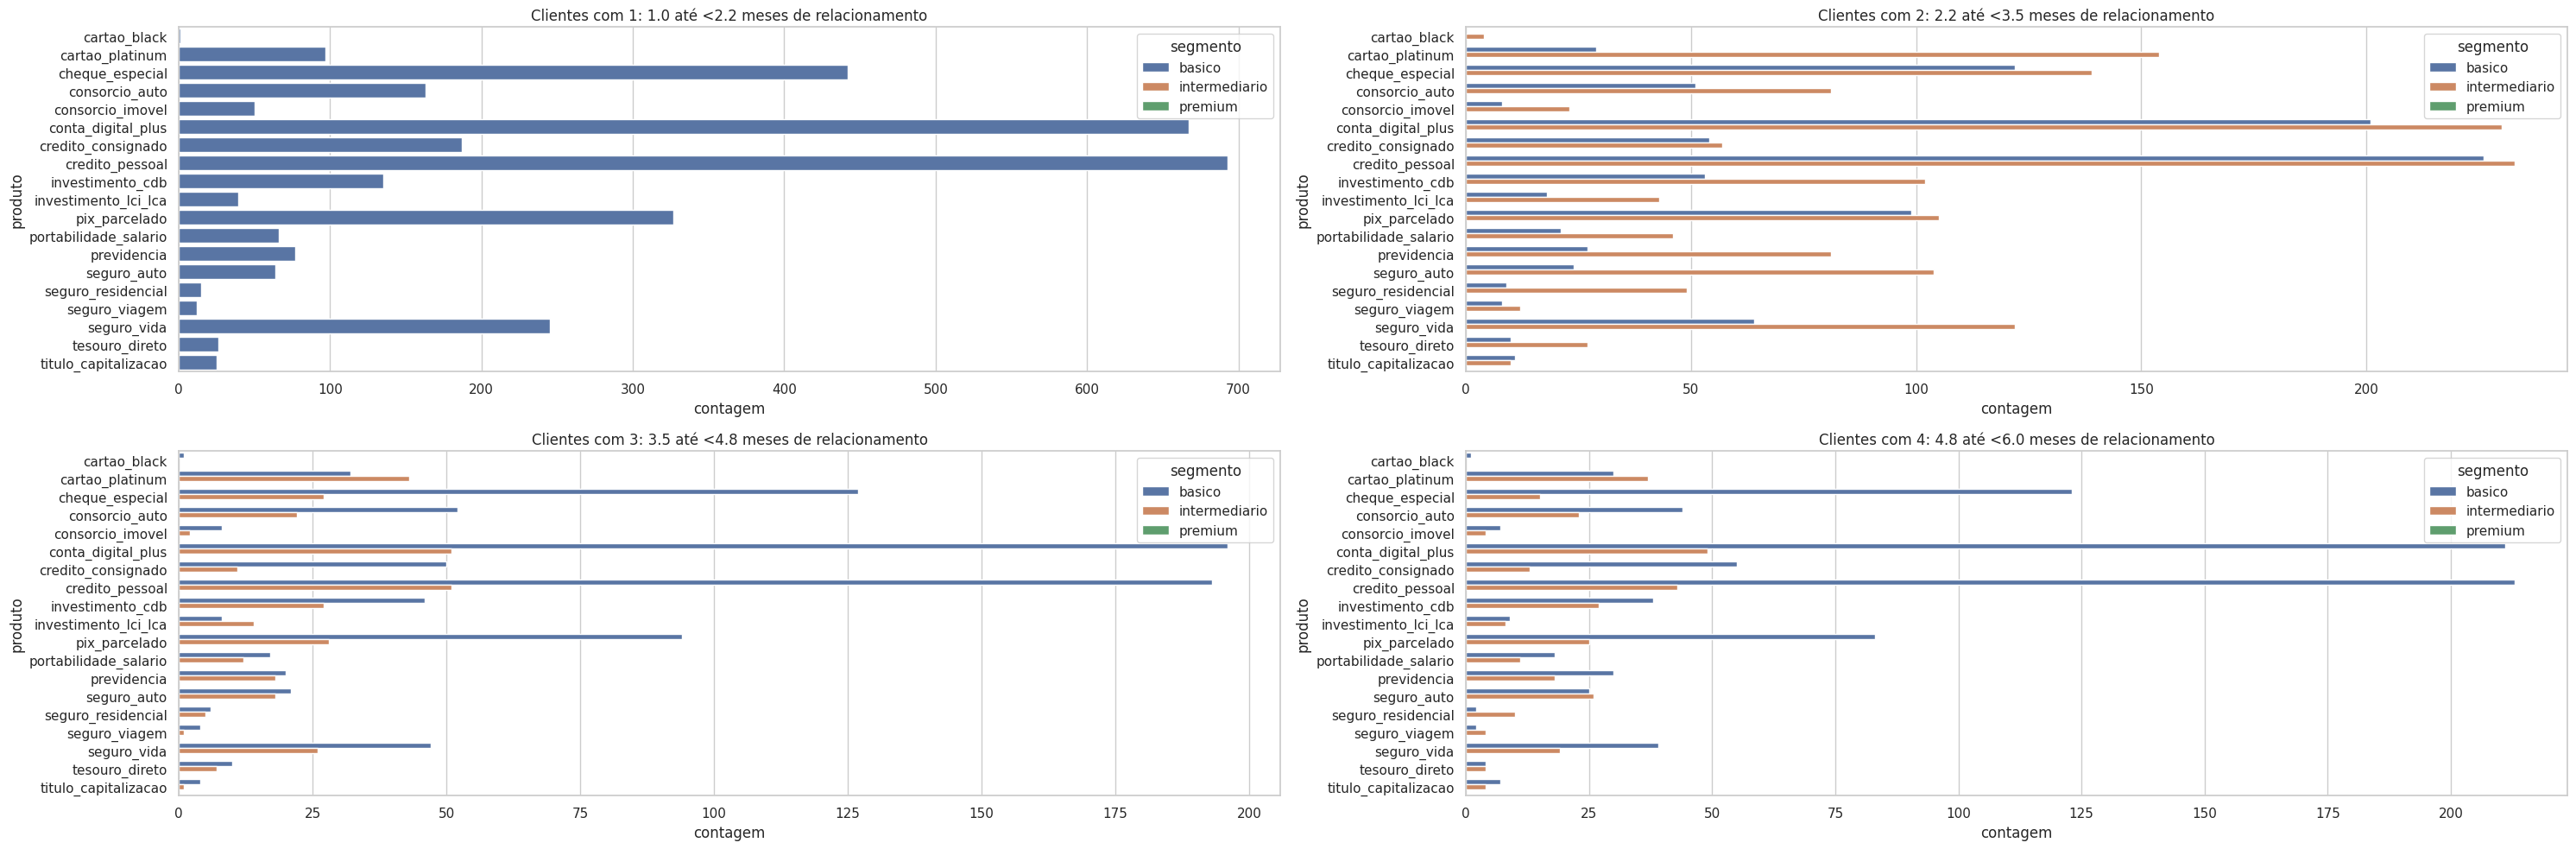

In [15]:
contratos_por_segmento_permanencia(
    df_contratos, df_clientes[df_clientes["qtd_meses_cliente"] <= 6], 4
)

Abaixo, uma visão do dataset completo sem o filtro de meses.

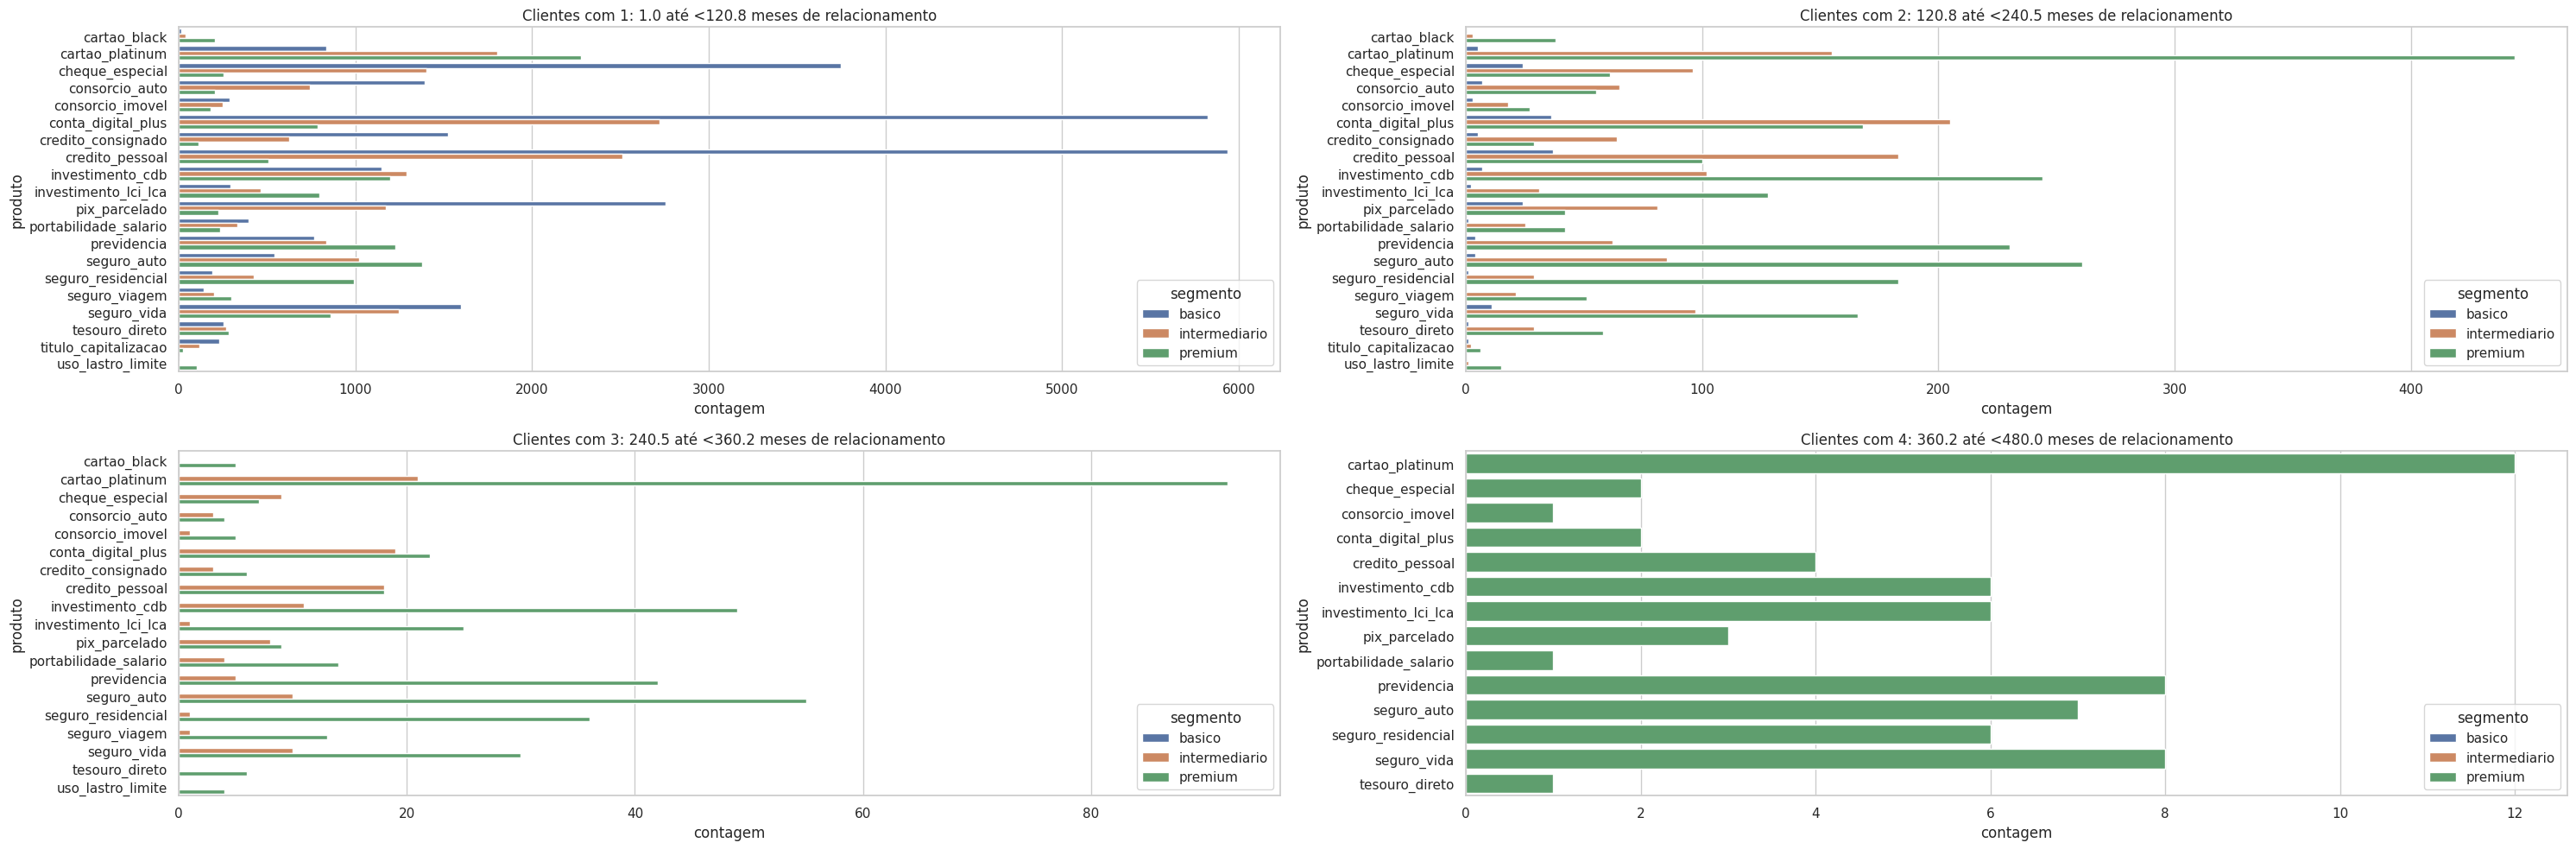

In [16]:
contratos_por_segmento_permanencia(df_contratos, df_clientes, 4)

Podemos ver que que realmente existe uma progressão no tempo e segmentos mais altos, o que reflete na carteira de produtos.

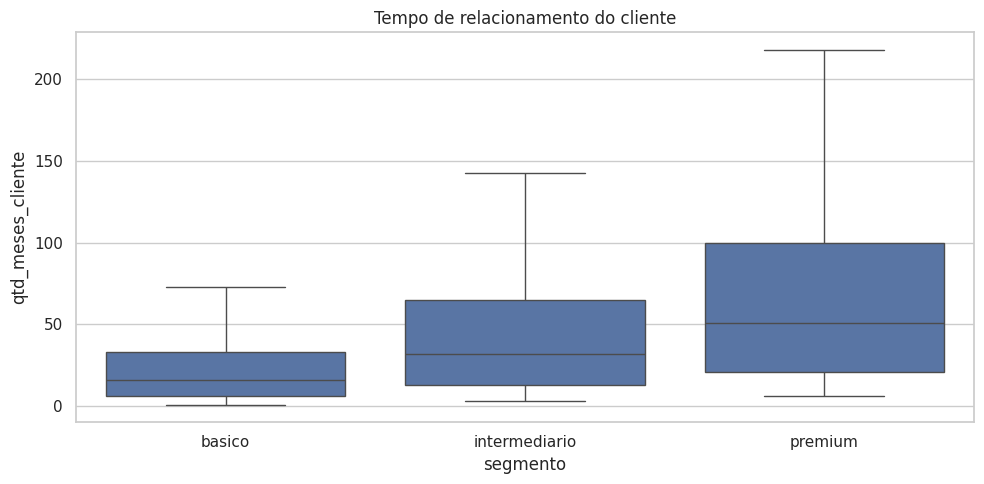

In [17]:
tempo_relacionamento_cliente(df_clientes)

## Correlação de produtos

É interessante perceber que produtos similares acabam tendo uma (fraca) correlação negativa. Podemos ver essa relação com produtos de crédito para os segmentos básicos e intermediários, enquanto no segmento premium é mais comum os cartões apresentam essa dinâmica.

Não parece um problema muito bom para usar uma estratégia de "cesta de produtos", já que há pouca correlação positiva entre os produtos.

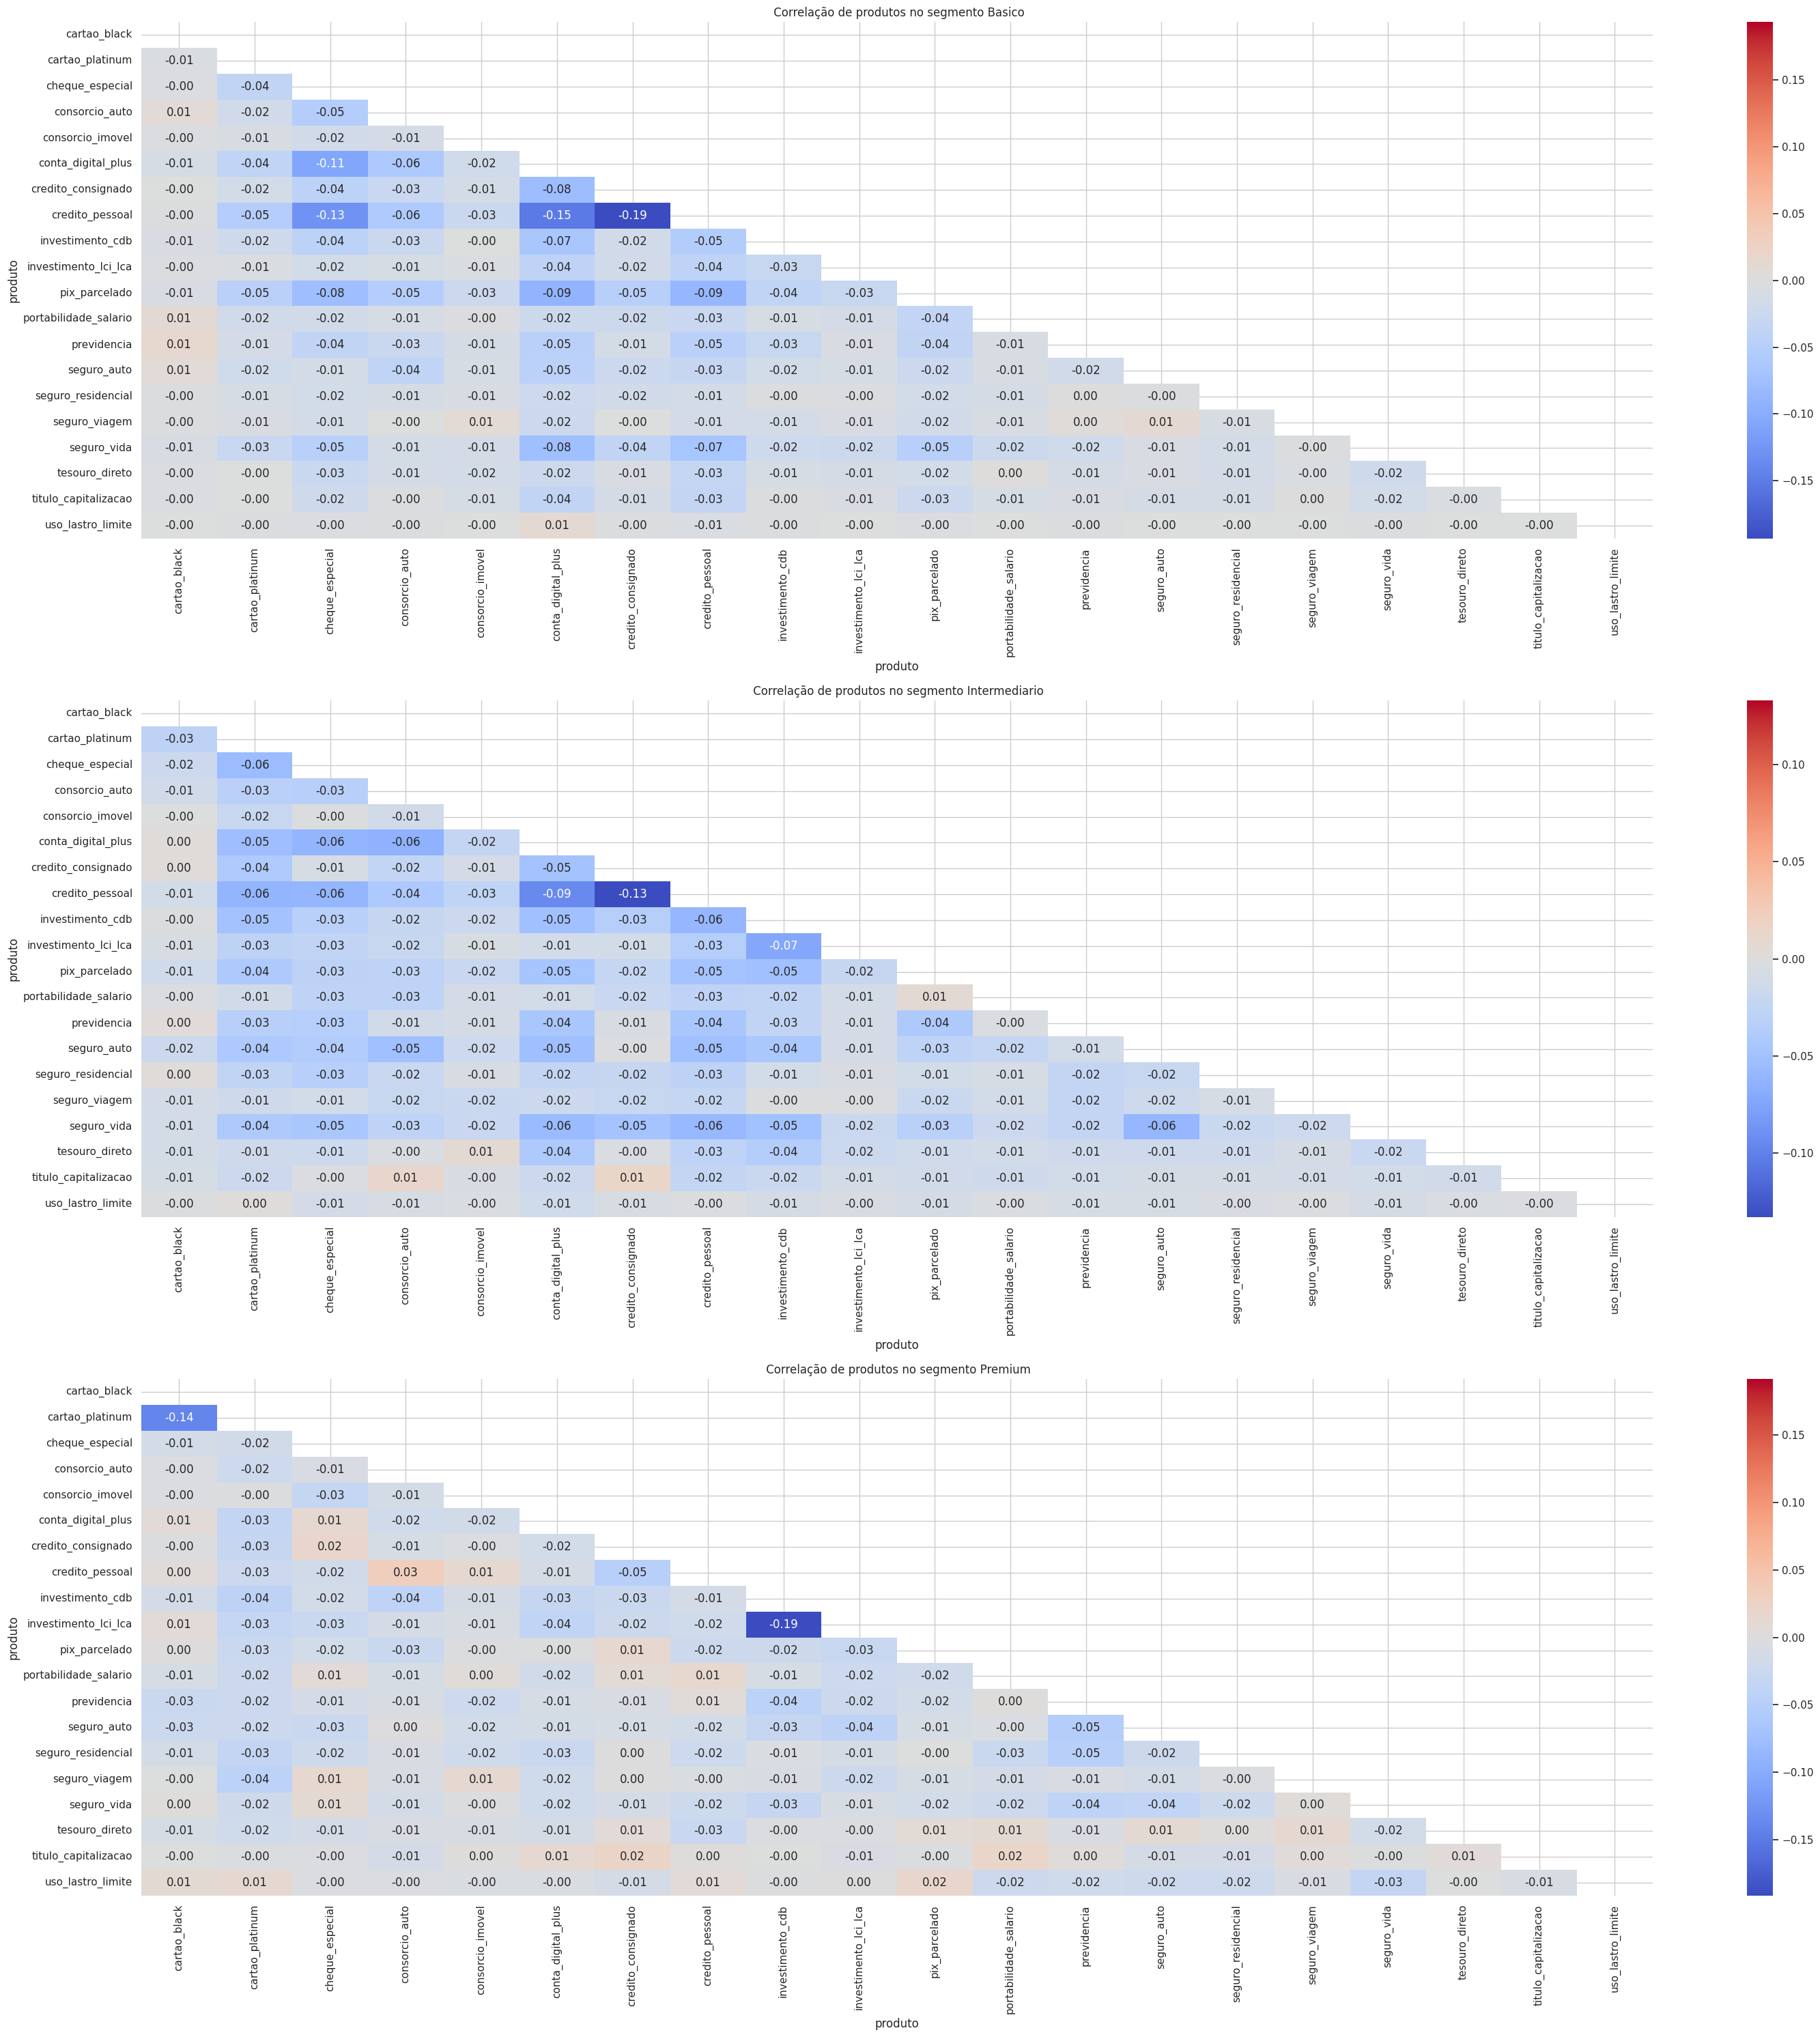

In [18]:
correlacao_produtos_por_segmento(df_contratos, df_clientes)

# Análise de clientes

A última base a ser avaliada é de clientes e suas características

In [19]:
def valores_faltantes(df_clientes: pd.DataFrame):
    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        (
            df_clientes.isna().sum().sort_values(ascending=False)
            / df_clientes["id_cliente"].count()
        )
        * 100,
        orient="h",
    )

    ax.set_title("Valores faltantes na base de clientes")

    plt.show()


def _preparar_clientes_xgboost(df_clientes: pd.DataFrame) -> pd.DataFrame:
    return (
        df_clientes.assign(
            segmento=lambda df: (
                df["segmento"]
                .replace({"basico": 1, "intermediario": 2, "premium": 3})
                .astype(np.uint8)
            )
        )
        .join(
            pd.get_dummies(
                df_clientes["canal_preferencial"],
                dtype=np.uint8,
                prefix="canal_preferencial",
                prefix_sep="_",
            )
        )
        .join(
            pd.get_dummies(
                df_clientes["uf"],
                dtype=np.uint8,
                prefix="uf",
                prefix_sep="_",
            )
        )
        .join(
            pd.get_dummies(
                df_clientes["genero"],
                dtype=np.uint8,
                prefix="genero",
                prefix_sep="_",
            )
        )
        .drop(columns=["canal_preferencial", "uf", "genero"])
    )


def _calcular_shap(dataset: pd.DataFrame):

    X = dataset.drop(columns=["id_cliente", "target"])
    y = dataset["target"]

    modelo = xgb.XGBClassifier(enable_categorical=True, random_state=42)
    modelo.fit(X, y)

    explainer = shap.Explainer(modelo, X)
    shap_values = explainer(X)

    media_abs_shap = np.mean(np.abs(shap_values.values), axis=0)

    df_importancia = pd.DataFrame(
        {"variavel": X.columns, "importancia_shap": media_abs_shap}
    ).sort_values(by="importancia_shap", ascending=False)

    return explainer, shap_values, df_importancia


def calcular_shap_wrapper(produto, df_clientes_xgboost, df_interacoes):

    dataset = pd.merge(
        df_clientes_xgboost,
        df_interacoes.query("posicao_exibicao <= 5.")
        .query(f"produto == '{produto}'")[["contratou", "id_cliente"]]
        .rename(columns={"contratou": "target"}),
        on="id_cliente",
    )

    _, _, df_importancia = _calcular_shap(dataset)

    return df_importancia.assign(produto=produto)


def graficos_importancia_variavel_produto(df_importancia: pd.DataFrame):
    produtos = df_importancia["produto"].drop_duplicates()
    num_cols = len(produtos)
    cols = min(3, num_cols)
    rows = (num_cols + cols - 1) // cols

    _, axes = plt.subplots(rows, cols, figsize=(20 * cols, 5 * rows + 2))
    axes = np.atleast_1d(axes).flatten()

    for i, produto in enumerate(produtos):
        axes[i].set_title(produto)

        sns.barplot(
            data=df_importancia.query(f"produto == '{produto}'").sort_values(
                by="importancia_shap", ascending=False
            )[:10],
            x="importancia_shap",
            y="variavel",
            ax=axes[i],
            orient="h",
        )


def rank_variaveis(df_importancia: pd.DataFrame):
    return (
        df_importancia.assign(
            rank_shap_produto=lambda df: df.groupby("produto")["importancia_shap"].rank(
                method="min"
            )
        )
        .groupby("variavel")
        .agg({"rank_shap_produto": "sum"})
        .sort_values(by="rank_shap_produto", ascending=False)
    )


def grafico_importancia_variavel_geral(df_importancia: pd.DataFrame):

    plt.figure(figsize=(15, 10))

    df_rank_variaveis = rank_variaveis(df_importancia)

    ax = sns.barplot(
        data=df_rank_variaveis[:20],
        x="rank_shap_produto",
        y="variavel",
    )

    ax.set_title("20 variáveis mais utilizadas")

    plt.show()


def plotar_histograma_variavel_cliente(
    df_clientes: pd.DataFrame, criterio_agrupamento: str, colunas_plot: list[str]
):

    num_cols = len(colunas_plot)
    cols = min(3, num_cols)
    rows = (num_cols + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = np.atleast_1d(axes).flatten()

    if num_cols == 1:
        axes = [axes]

    for i, coluna in enumerate(colunas_plot):
        if df_clientes[coluna].dtype in ["int64", "float64"]:
            sns.histplot(
                data=df_clientes,
                x=coluna,
                hue=criterio_agrupamento,
                kde=True,
                element="step",
                ax=axes[i],
            )
            axes[i].set_title(f"Distribuição de {coluna} por {criterio_agrupamento}")
        else:
            sns.countplot(
                data=df_clientes, x=coluna, hue=criterio_agrupamento, ax=axes[i]
            )
            axes[i].set_title(f"Contagem de {coluna} por {criterio_agrupamento}")
            axes[i].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plotar_boxplot_variavel_cliente(
    df_clientes: pd.DataFrame,
    criterio_agrupamento: str,
    colunas_plot: list[str],
    show_outliers=True,
):

    colunas_numericas = [
        col for col in colunas_plot if df_clientes[col].dtype in ["int64", "float64"]
    ]

    num_cols = len(colunas_numericas)

    if num_cols == 0:
        print("Nenhuma coluna numérica encontrada na lista fornecida.")
        return

    cols = min(3, num_cols)
    rows = (num_cols + cols - 1) // cols
    _, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows + 2))
    axes = np.atleast_1d(axes).flatten()

    for i, coluna in enumerate(colunas_numericas):
        sns.boxplot(
            data=df_clientes,
            x=criterio_agrupamento,
            y=coluna,
            ax=axes[i],
            showfliers=show_outliers,
        )

    for ax in axes[num_cols:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


# Valores faltantes

A falta de informações são referentes a valores de comportamento financeiro (e.g. gastos, invesimentos e score). Os valores ficam em torno de 2,5% da base e os dados cadastrais básicos não possuem missing values.

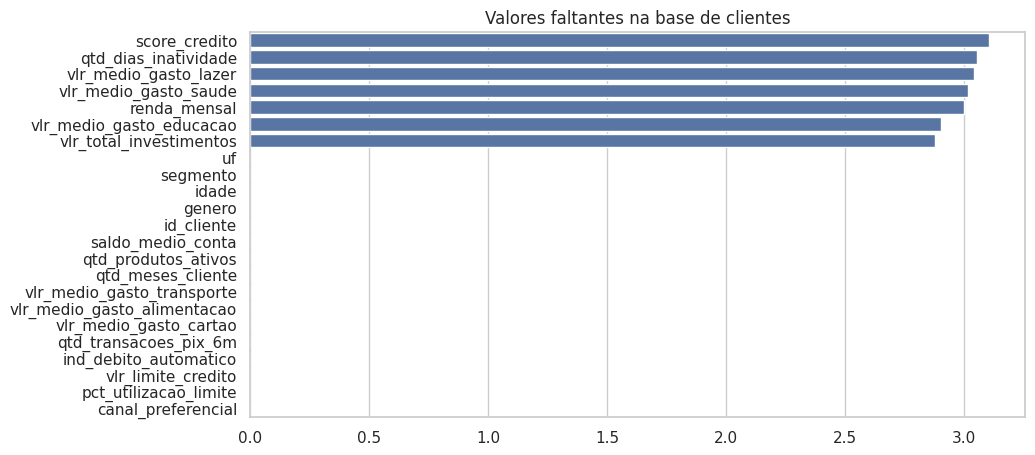

In [20]:
valores_faltantes(df_clientes)

# Variáveis correlacionadas

A base de clientes possue diversas variáveis, uma estratégia para identificar as mais importantes é usar os valores [SHAP](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html). Minha ideia é compreender os valores mais utilizados SHAP em um classificador XGBoost, para identificar a partir de um modelo quais variáveis são mais relevantes para a predição.

In [21]:
df_clientes_xgboost = _preparar_clientes_xgboost(df_clientes)

df_importancia = pd.concat(
    Parallel(n_jobs=os.cpu_count())(
        delayed(calcular_shap_wrapper)(produto, df_clientes_xgboost, df_interacoes)
        for produto in df_interacoes["produto"].drop_duplicates().to_list()
    )
)

/home/gdarruda/Projects/case-sistema-recomendacao-resolucao/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:880: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(sum_val - model_output)
 65%|=============       | 5589/8535 [00:23<00:12]        /home/gdarruda/Projects/case-sistema-recomendacao-resolucao/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:880: RuntimeWarning: invalid value encountered in subtract
  diff = np.abs(sum_val - model_output)
 99%|===================| 39957/40244 [02:05<00:00]        

Abaixo podemos ver as 10 variáveis mais importantes para identificar contratação de cada produto. Em geral, foram destacadas variáveis relacionadas a gastos, renda e crédito. Produtos específicos dependem de características próprias, como é o caso de idade para seguro de vida e canal preferido para conta digital.

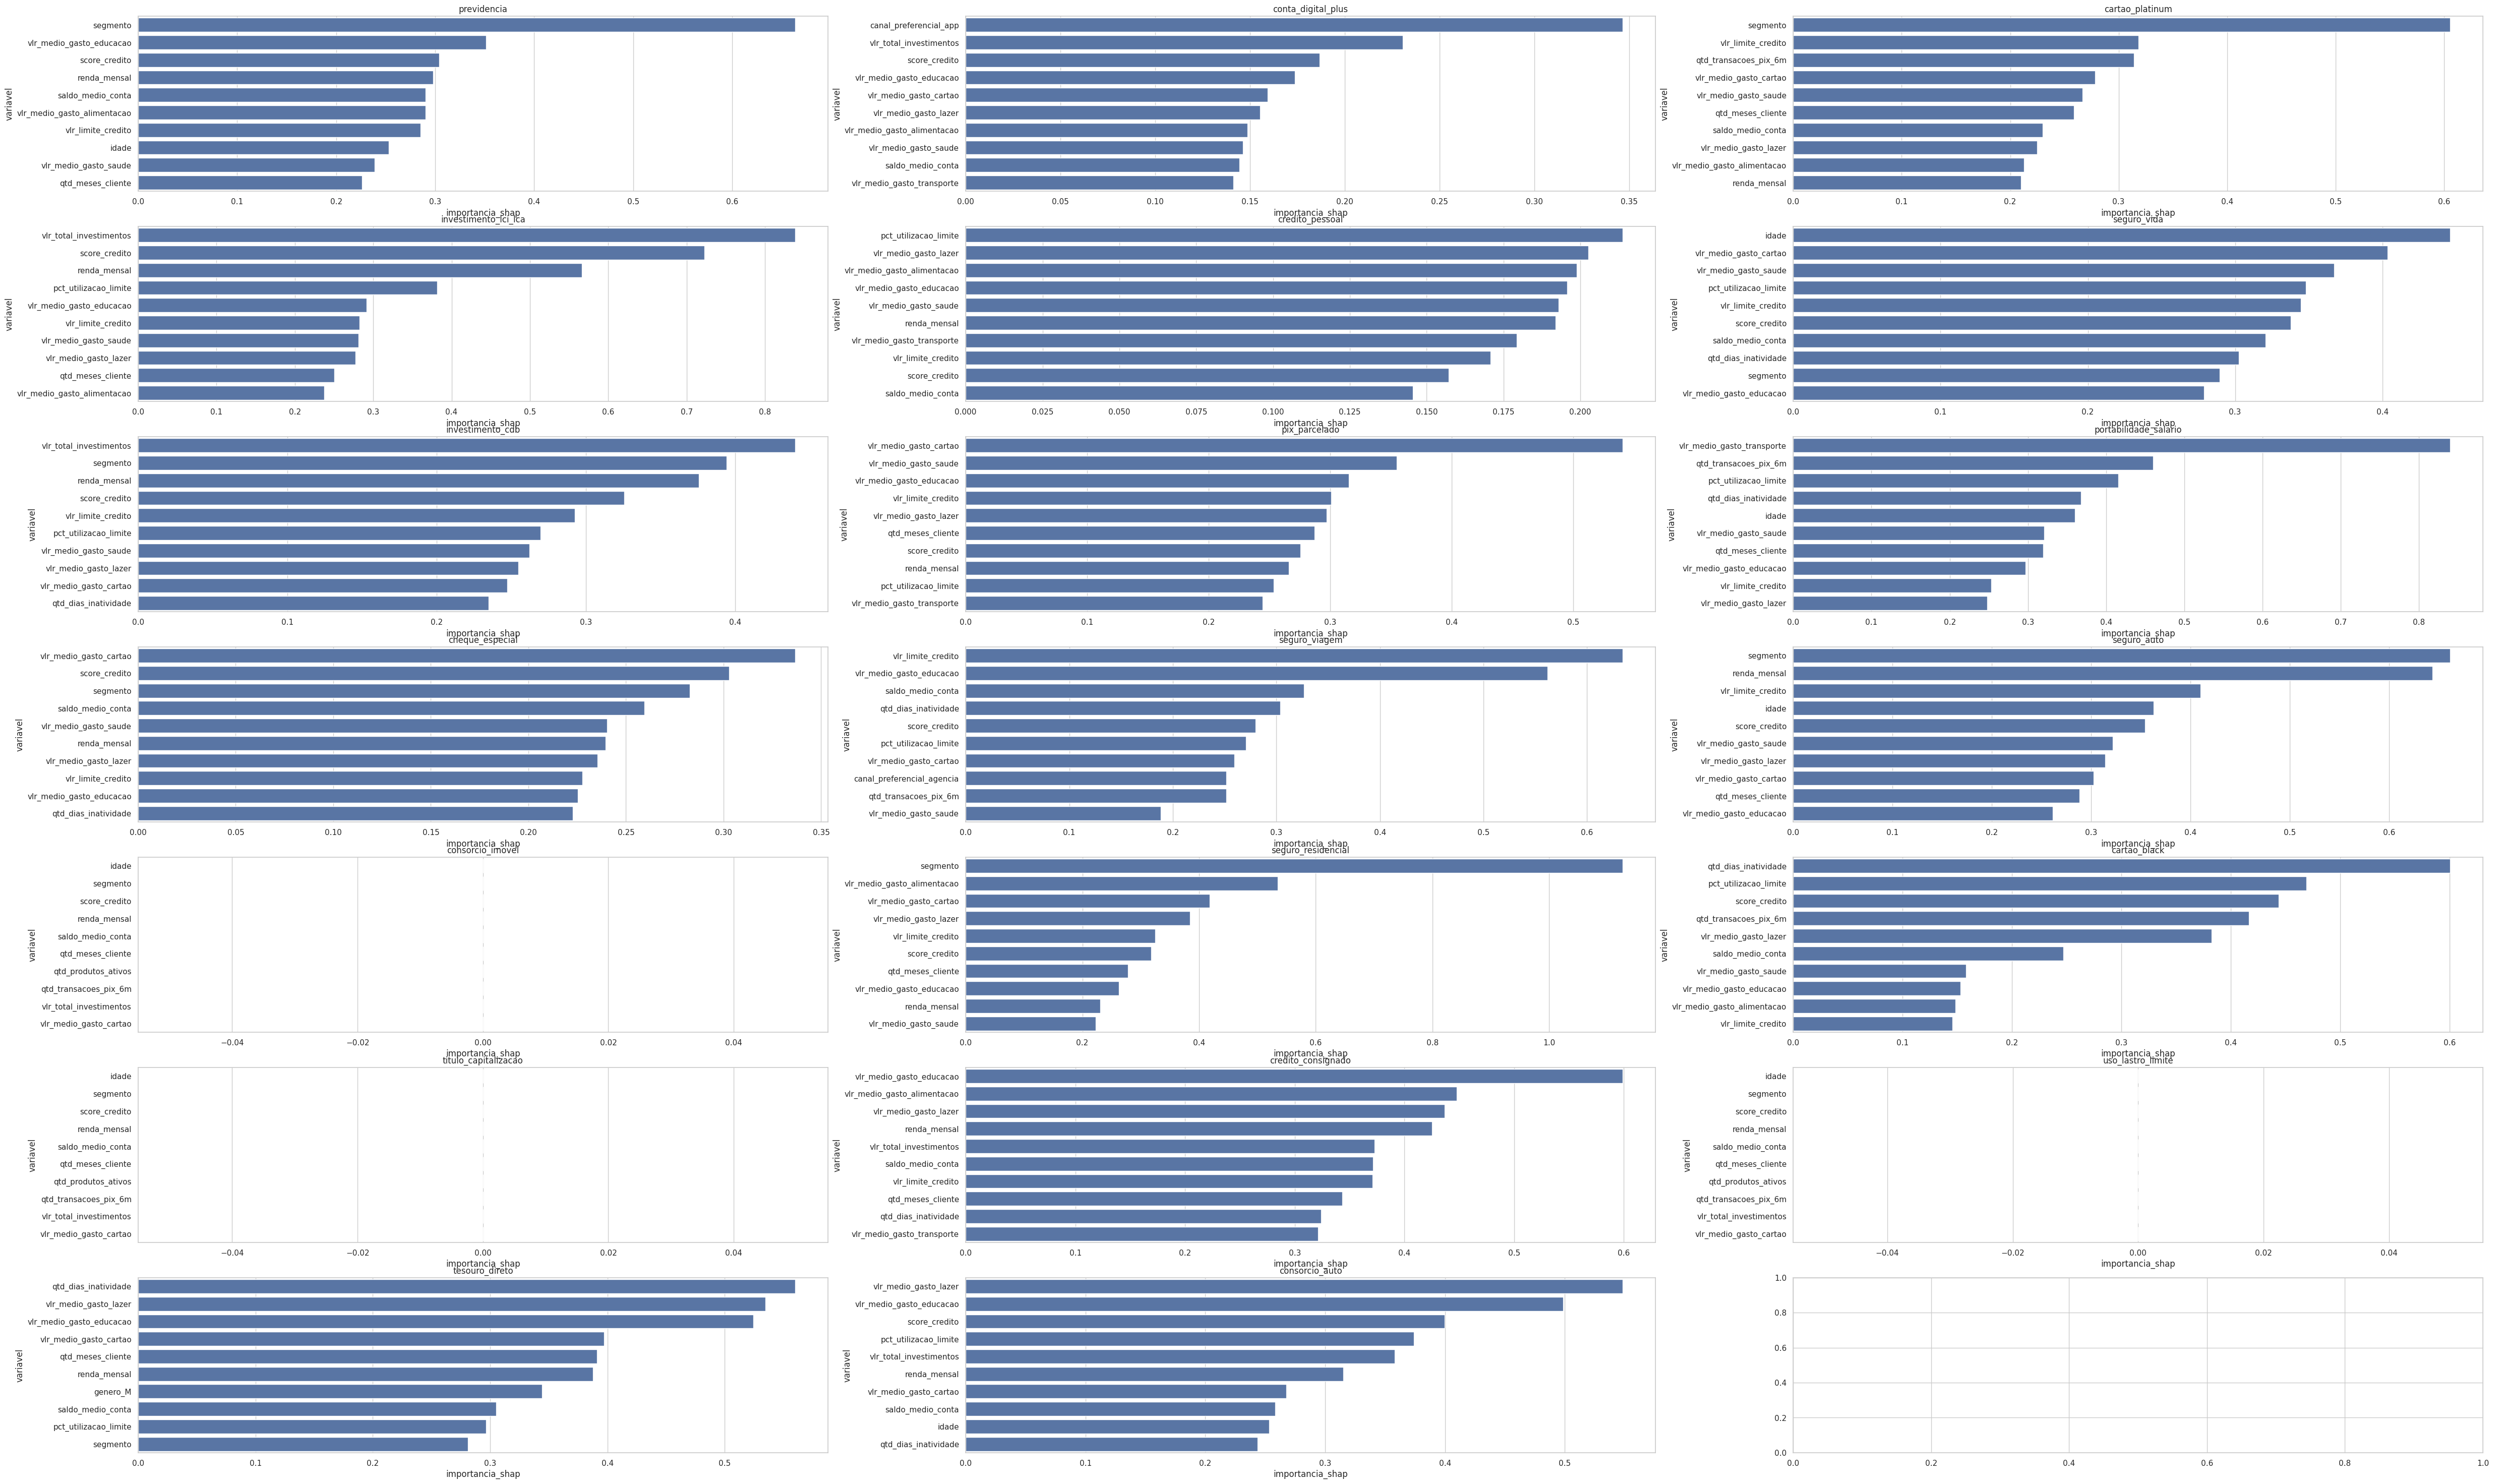

In [22]:
graficos_importancia_variavel_produto(df_importancia)

Abaixo, podemos ver as variáveis mais utilizadas, considerando todos os classificadores treinados por produto. Fica mais claro como as variáveis referentes a gastos, rendas e crédito predominam.

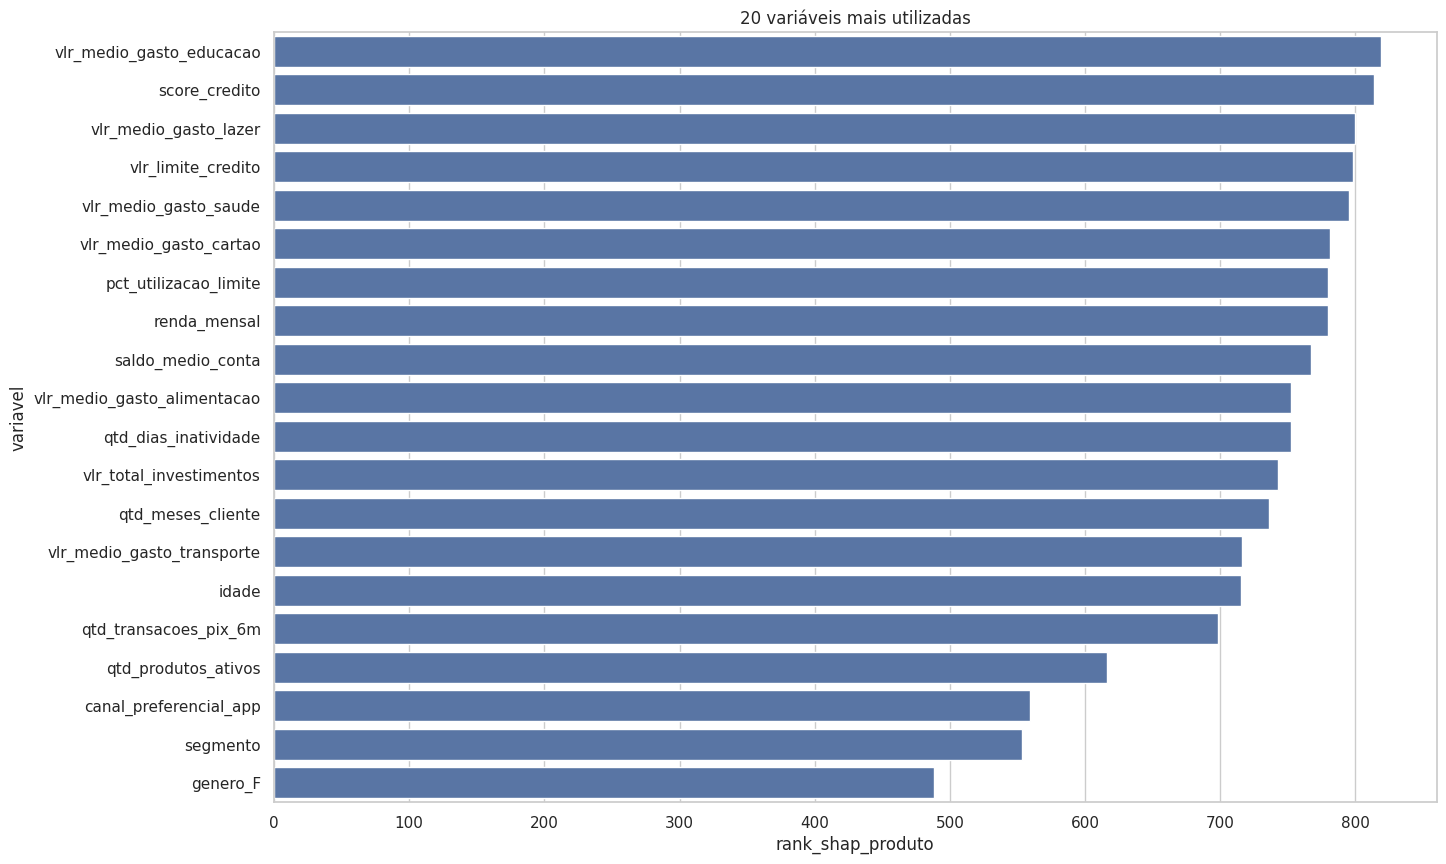

In [23]:
grafico_importancia_variavel_geral(df_importancia)

In [24]:
df_rank_variaveis = rank_variaveis(df_importancia)

Abaixo, a dstribuição das variáveis mais importantes por segmento. Como esperado – a distribuição variáveis relacionadas a gastos, renda e crédito – muda de segmento para segmento, o que a torna um bom jeito de fazer um classificador baseline como é na solução atual.

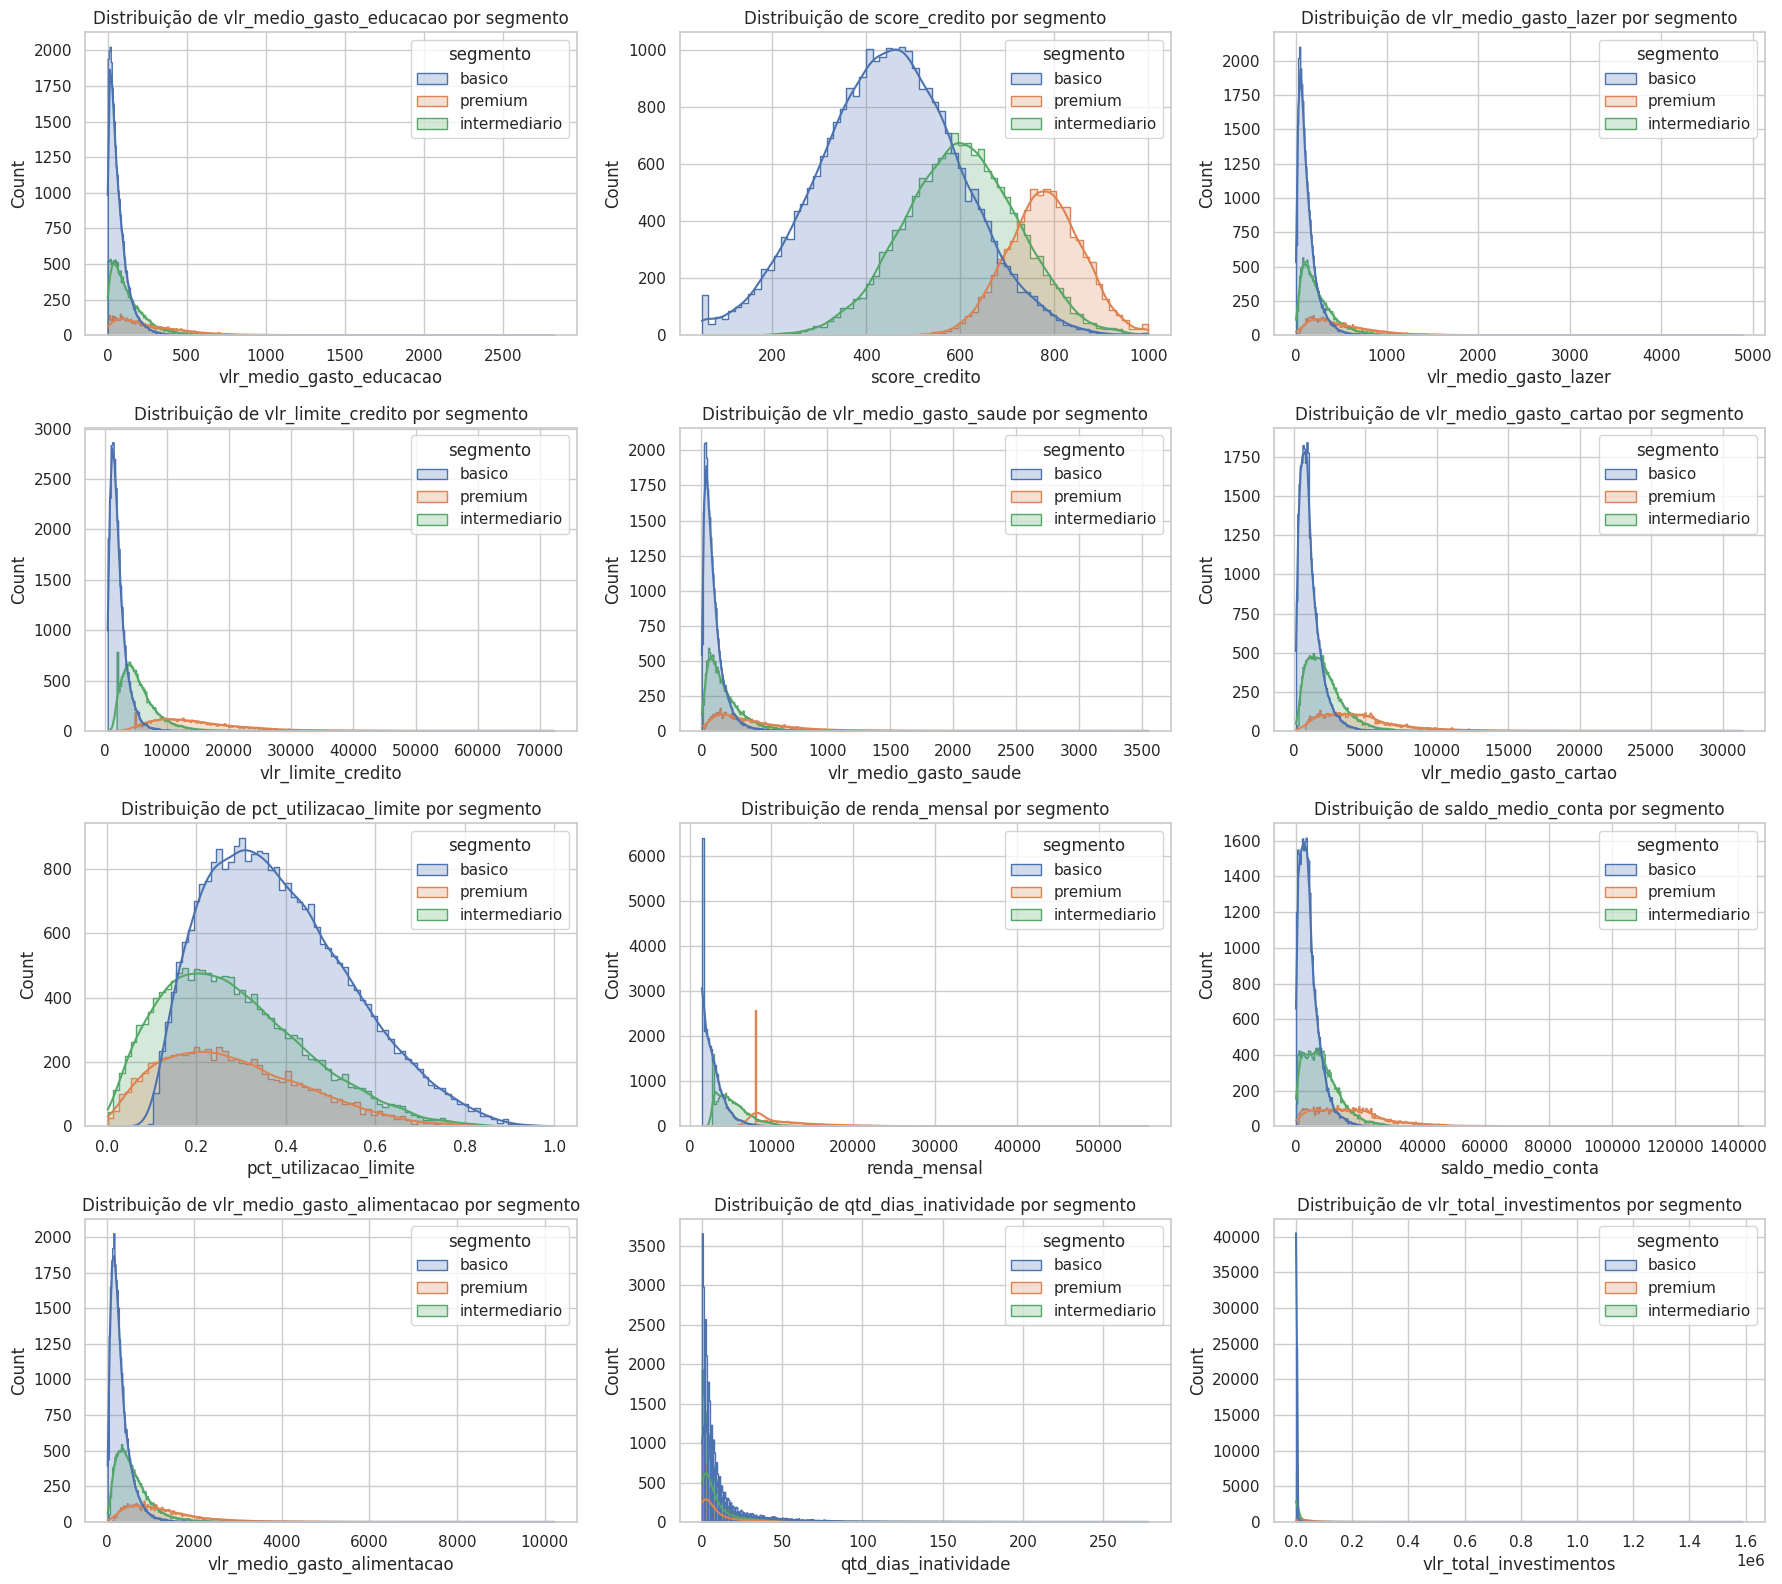

In [25]:
plotar_histograma_variavel_cliente(
    df_clientes, "segmento", df_rank_variaveis.index.to_list()[:12]
)

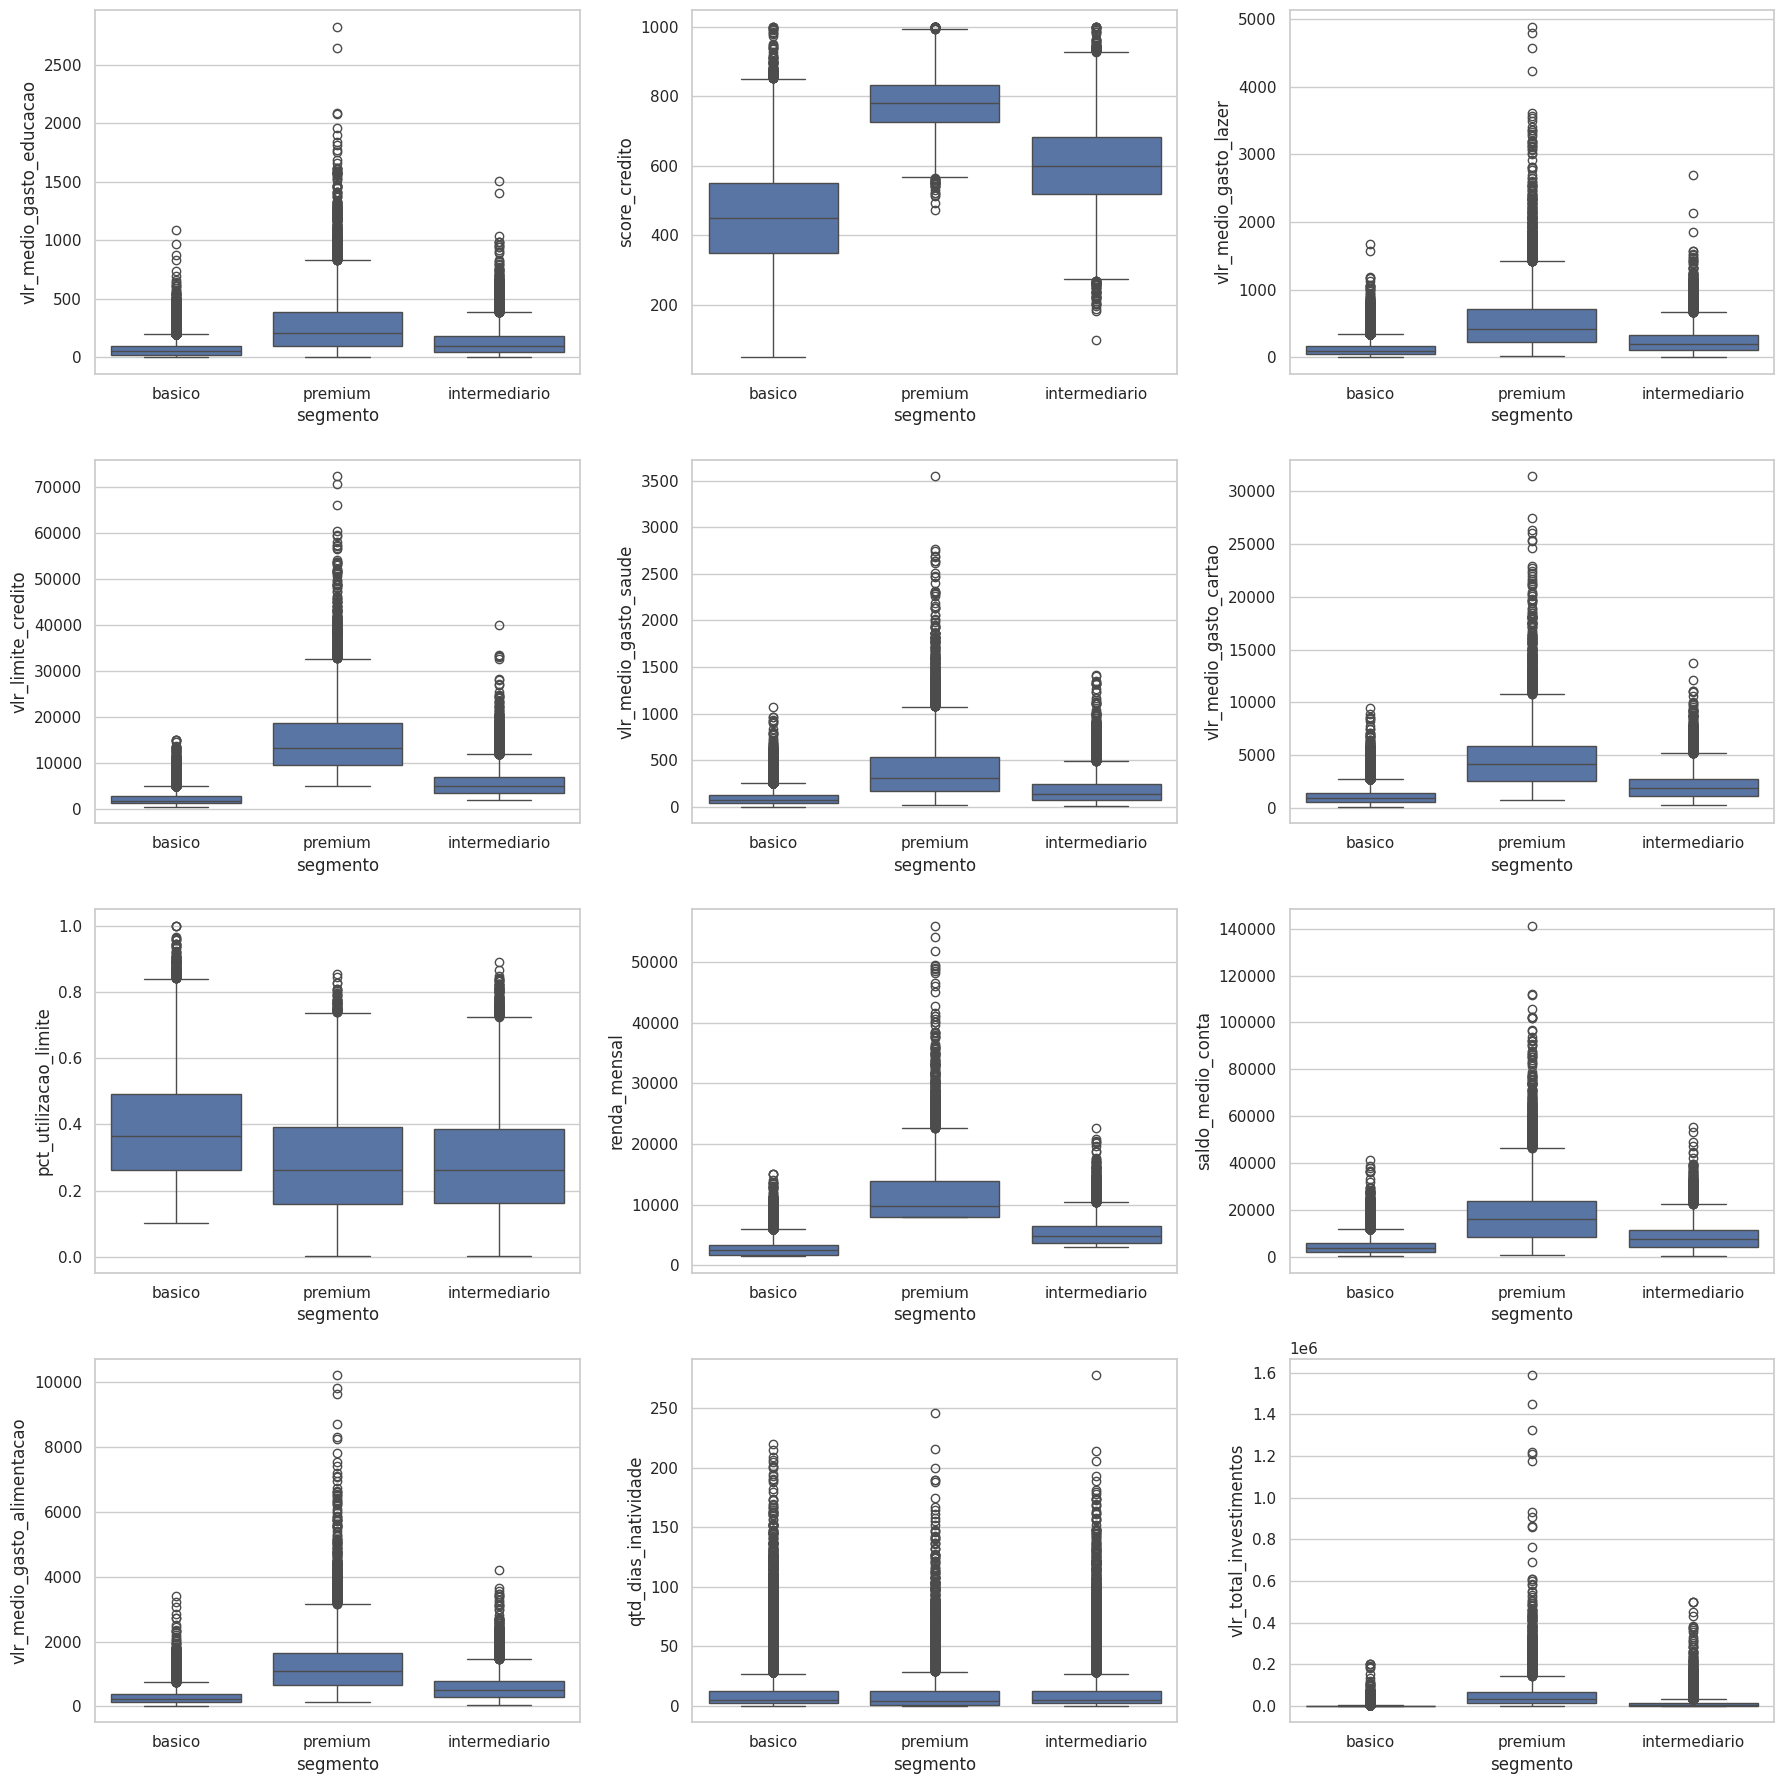

In [26]:
plotar_boxplot_variavel_cliente(
    df_clientes, "segmento", df_rank_variaveis.index.to_list()[:12], show_outliers=True
)